## Credit Card Users Churn Prediction

## Problem Statement

### Business Context

The Thera bank recently saw a steep decline in the number of users of their credit card, credit cards are a good source of income for banks because of different kinds of fees charged by the banks like annual fees, balance transfer fees, and cash advance fees, late payment fees, foreign transaction fees, and others. Some fees are charged to every user irrespective of usage, while others are charged under specified circumstances.

Customers’ leaving credit cards services would lead bank to loss, so the bank wants to analyze the data of customers and identify the customers who will leave their credit card services and reason for same – so that bank could improve upon those areas

You as a Data scientist at Thera bank need to come up with a classification model that will help the bank improve its services so that customers do not renounce their credit cards

### Data Description

* CLIENTNUM: Client number. Unique identifier for the customer holding the account
* Attrition_Flag: Internal event (customer activity) variable - if the account is closed then "Attrited Customer" else "Existing Customer"
* Customer_Age: Age in Years
* Gender: Gender of the account holder
* Dependent_count: Number of dependents
* Education_Level: Educational Qualification of the account holder - Graduate, High School, Unknown, Uneducated, College(refers to college student), Post-Graduate, Doctorate
* Marital_Status: Marital Status of the account holder
* Income_Category: Annual Income Category of the account holder
* Card_Category: Type of Card
* Months_on_book: Period of relationship with the bank (in months)
* Total_Relationship_Count: Total no. of products held by the customer
* Months_Inactive_12_mon: No. of months inactive in the last 12 months
* Contacts_Count_12_mon: No. of Contacts in the last 12 months
* Credit_Limit: Credit Limit on the Credit Card
* Total_Revolving_Bal: Total Revolving Balance on the Credit Card
* Avg_Open_To_Buy: Open to Buy Credit Line (Average of last 12 months)
* Total_Amt_Chng_Q4_Q1: Change in Transaction Amount (Q4 over Q1)
* Total_Trans_Amt: Total Transaction Amount (Last 12 months)
* Total_Trans_Ct: Total Transaction Count (Last 12 months)
* Total_Ct_Chng_Q4_Q1: Change in Transaction Count (Q4 over Q1)
* Avg_Utilization_Ratio: Average Card Utilization Ratio

#### What Is a Revolving Balance?

- If we don't pay the balance of the revolving credit account in full every month, the unpaid portion carries over to the next month. That's called a revolving balance


##### What is the Average Open to buy?

- 'Open to Buy' means the amount left on your credit card to use. Now, this column represents the average of this value for the last 12 months.

##### What is the Average utilization Ratio?

- The Avg_Utilization_Ratio represents how much of the available credit the customer spent. This is useful for calculating credit scores.


##### Relation b/w Avg_Open_To_Buy, Credit_Limit and Avg_Utilization_Ratio:

- ( Avg_Open_To_Buy / Credit_Limit ) + Avg_Utilization_Ratio = 1

### **Please read the instructions carefully before starting the project.**
This is a commented Jupyter IPython Notebook file in which all the instructions and tasks to be performed are mentioned.
* Blanks '_______' are provided in the notebook that
needs to be filled with an appropriate code to get the correct result. With every '_______' blank, there is a comment that briefly describes what needs to be filled in the blank space.
* Identify the task to be performed correctly, and only then proceed to write the required code.
* Fill the code wherever asked by the commented lines like "# write your code here" or "# complete the code". Running incomplete code may throw error.
* Please run the codes in a sequential manner from the beginning to avoid any unnecessary errors.
* Add the results/observations (wherever mentioned) derived from the analysis in the presentation and submit the same.


## Importing necessary libraries

In [5]:
# Installing the libraries with the specified version.
# uncomment and run the following line if Google Colab is being used
!pip install imbalanced-learn==0.10.1 xgboost==2.0.3 -q --user

In [6]:
# Installing the libraries with the specified version.
# uncomment and run the following lines if Jupyter Notebook is being used
# !pip install scikit-learn==1.2.2 seaborn==0.13.1 matplotlib==3.7.1 numpy==1.25.2 pandas==1.5.3 imblearn==0.12.0 xgboost==2.0.3 -q --user
# !pip install --upgrade -q threadpoolctl

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again*.

In [7]:
# Installing the libraries with the specified version.

import pandas as pd
import numpy as np
from sklearn import metrics
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

# Model Selection & Hyper Parameters
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV

# Decision Tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

# Over & Under Sampling
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# Sklearn Metrics
from sklearn.metrics import confusion_matrix
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from sklearn.metrics import make_scorer


## Loading the dataset

In [8]:
# Load Files

from google.colab import drive
drive.mount('/content/drive')

pd_card = pd.read_csv('/content/drive/My Drive/AIML_Class_Files/AdvMachineLearning_Capstone/BankChurners.csv')

Mounted at /content/drive


## Data Overview

In [9]:
# Visualize Sample Data

pd_card.head(20)

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,NaN,Less than $40K,Blue,34,...,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000
5,713061558,Existing Customer,44,M,2,Graduate,Married,$40K - $60K,Blue,36,...,1,2,4010.0,1247,2763.0,1.376,1088,24,0.846,0.311
6,810347208,Existing Customer,51,M,4,NaN,Married,$120K +,Gold,46,...,1,3,34516.0,2264,32252.0,1.975,1330,31,0.722,0.066
7,818906208,Existing Customer,32,M,0,High School,NaN,$60K - $80K,Silver,27,...,2,2,29081.0,1396,27685.0,2.204,1538,36,0.714,0.048
8,710930508,Existing Customer,37,M,3,Uneducated,Single,$60K - $80K,Blue,36,...,2,0,22352.0,2517,19835.0,3.355,1350,24,1.182,0.113
9,719661558,Existing Customer,48,M,2,Graduate,Single,$80K - $120K,Blue,36,...,3,3,11656.0,1677,9979.0,1.524,1441,32,0.882,0.144


In [10]:
# Get Shape of data

pd_card.shape

(10127, 21)

In [11]:
# Describe the Dataset

pd_card.describe().T

,count,mean,std,min,25%,50%,75%,max
CLIENTNUM,10127.0,7.391776e+08,3.690378e+07,708082083.0,7.130368e+08,7.179264e+08,7.731435e+08,8.283431e+08
Customer_Age,10127.0,4.632596e+01,8.016814e+00,26.0,4.100000e+01,4.600000e+01,5.200000e+01,7.300000e+01
Dependent_count,10127.0,2.346203e+00,1.298908e+00,0.0,1.000000e+00,2.000000e+00,3.000000e+00,5.000000e+00
Months_on_book,10127.0,3.592841e+01,7.986416e+00,13.0,3.100000e+01,3.600000e+01,4.000000e+01,5.600000e+01
Total_Relationship_Count,10127.0,3.812580e+00,1.554408e+00,1.0,3.000000e+00,4.000000e+00,5.000000e+00,6.000000e+00
Months_Inactive_12_mon,10127.0,2.341167e+00,1.010622e+00,0.0,2.000000e+00,2.000000e+00,3.000000e+00,6.000000e+00
Contacts_Count_12_mon,10127.0,2.455317e+00,1.106225e+00,0.0,2.000000e+00,2.000000e+00,3.000000e+00,6.000000e+00
Credit_Limit,10127.0,8.631954e+03,9.088777e+03,1438.3,2.555000e+03,4.549000e+03,1.106750e+04,3.451600e+04
Total_Revolving_Bal,10127.0,1.162814e+03,8.149873e+02,0.0,3.590000e+02,1.276000e+03,1.784000e+03,2.517000e+03
Avg_Open_To_Buy,10127.0,7.469140e+03,9.090685e+03,3.0,1.324500e+03,3.474000e+03,9.859000e+03,3.451600e+04


In [12]:
# Get Info on Dataset

pd_card.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CLIENTNUM                 10127 non-null  int64  
 1   Attrition_Flag            10127 non-null  object 
 2   Customer_Age              10127 non-null  int64  
 3   Gender                    10127 non-null  object 
 4   Dependent_count           10127 non-null  int64  
 5   Education_Level           8608 non-null   object 
 6   Marital_Status            9378 non-null   object 
 7   Income_Category           10127 non-null  object 
 8   Card_Category             10127 non-null  object 
 9   Months_on_book            10127 non-null  int64  
 10  Total_Relationship_Count  10127 non-null  int64  
 11  Months_Inactive_12_mon    10127 non-null  int64  
 12  Contacts_Count_12_mon     10127 non-null  int64  
 13  Credit_Limit              10127 non-null  float64
 14  Total_

### Observations

1. We have visualized the data and Info.
2. Our Target Variable / Dependant variable is Attrition_Flag
2. There are missing values in Marital Status, Education Level
3. There are Categorical variables that would need to be converted to numeric values using OnHotEncoding
  - Dependent_count
  - Education_Level
  - Marital_Status
  - Income_Category
  - Card_Category

## Exploratory Data Analysis (EDA)

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Questions**:

1. How is the total transaction amount distributed?
2. What is the distribution of the level of education of customers?
3. What is the distribution of the level of income of customers?
4. How does the change in transaction amount between Q4 and Q1 (`total_ct_change_Q4_Q1`) vary by the customer's account status (`Attrition_Flag`)?
5. How does the number of months a customer was inactive in the last 12 months (`Months_Inactive_12_mon`) vary by the customer's account status (`Attrition_Flag`)?
6. What are the attributes that have a strong correlation with each other?



#### The below functions need to be defined to carry out the Exploratory Data Analysis.

In [13]:
# function to plot a boxplot and a histogram along the same scale.


def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [14]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

In [15]:
# function to plot stacked bar chart

def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 1, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

In [16]:
### Function to plot distributions

def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

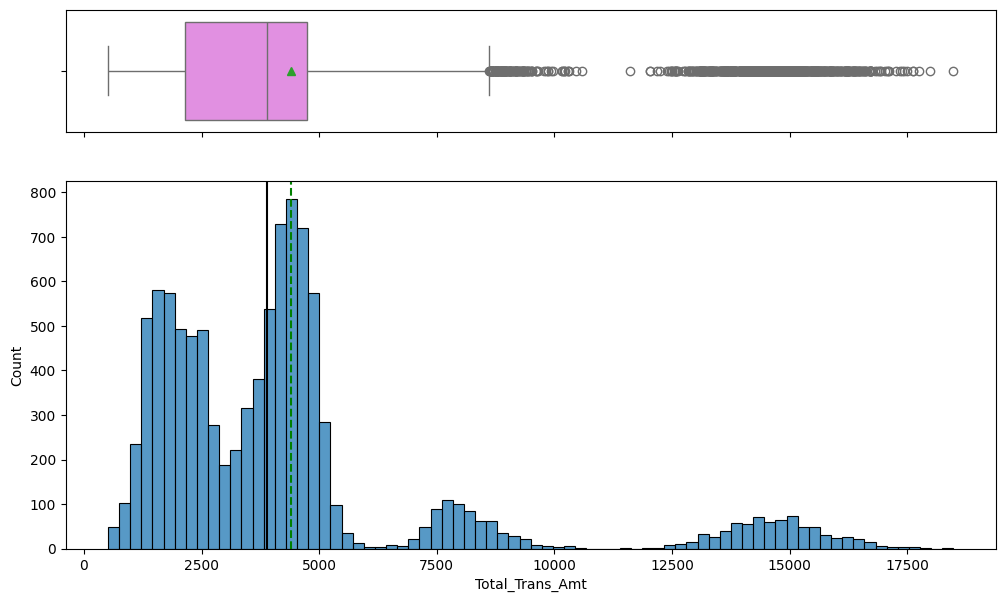

In [17]:
# Q1 - Distribution of Total Transaction Amount

histogram_boxplot(pd_card, 'Total_Trans_Amt')


### Obsrvations

1. Total Transaction Amount are Right skewed
2. Most of the Customers are in teh range of 500 - 6000
3. There are several outlier values, but we will not consider this sine DecisionClassifier can handle Missing Values and Outliers inherently.

<ipython-input-14-1e58b03272cc>:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


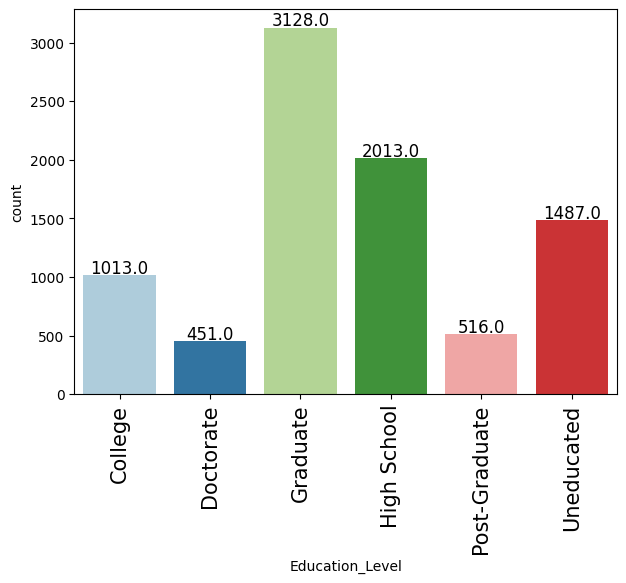

In [18]:
# Q2 - Distribution of Level of Education for Customers

labeled_barplot(pd_card, 'Education_Level');


### Observations

1. Graduates are the highest caregory of Customers
2. Followed by the High School educated customers.

<ipython-input-14-1e58b03272cc>:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


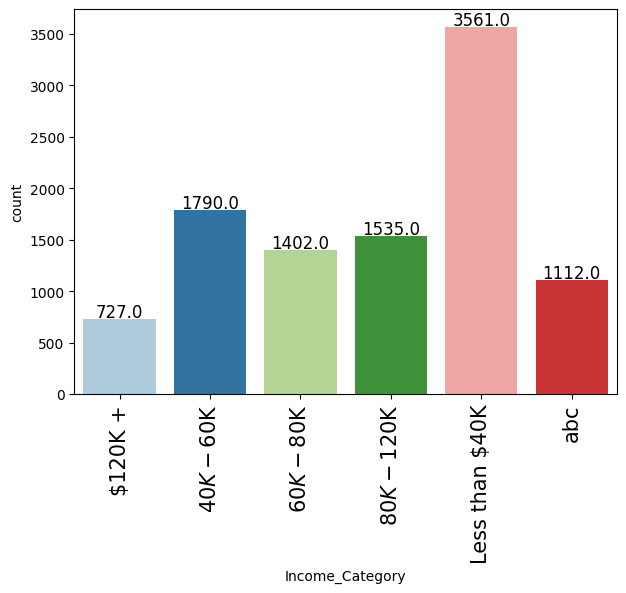

In [19]:
# Q3 - Distribution of Income for Custoemrs

labeled_barplot(pd_card, 'Income_Category')


### Observations

1. Highest category of custoemrs are < 40K
2. There is undefined category of customers 'abc'.
3. This we might need to impute / treat at later stage.

<ipython-input-16-3732c5f6b024>:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")
<ipython-input-16-3732c5f6b024>:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


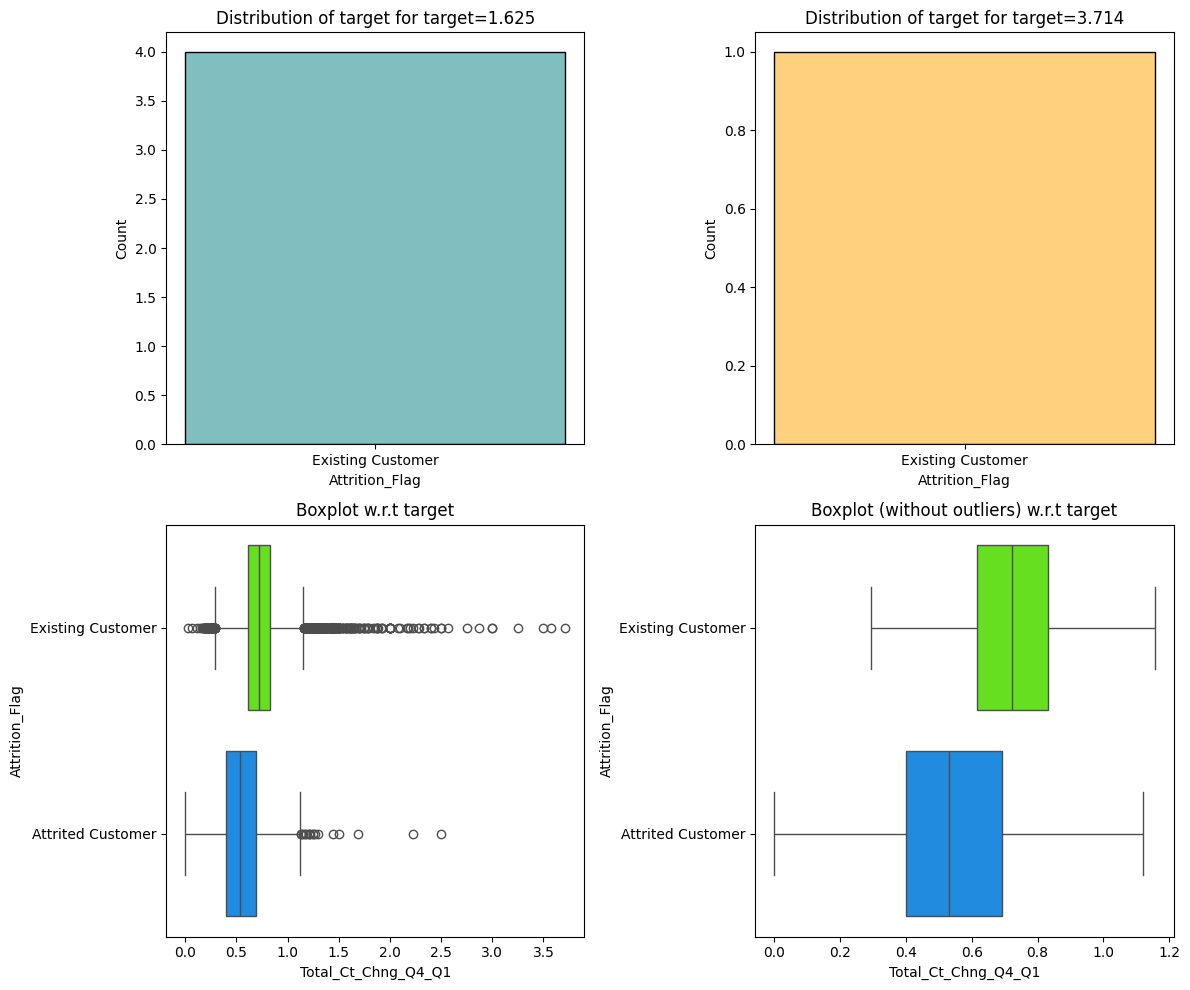

In [20]:
# Q4. How does the change in transaction amount between Q4 and Q1 (total_ct_change_Q4_Q1) vary by the customer's account status (Attrition_Flag)?

distribution_plot_wrt_target(pd_card, 'Attrition_Flag', 'Total_Ct_Chng_Q4_Q1')

### Observations

1. The Existing Customer has a higer median change on Q4 - Q1
2. Existing Custoemrs have outliers on both sides with less percentage of custoemrs outliers less than 25% and more setr of Customers past 75%.
Both Existign and Attribute Change Count distribtion is Right Skewed.


Months_Inactive_12_mon   0     1     2     3    4    5    6    All
Attrition_Flag                                                    
All                     29  2233  3282  3846  435  178  124  10127
Attrited Customer       15   100   505   826  130   32   19   1627
Existing Customer       14  2133  2777  3020  305  146  105   8500
------------------------------------------------------------------------------------------------------------------------


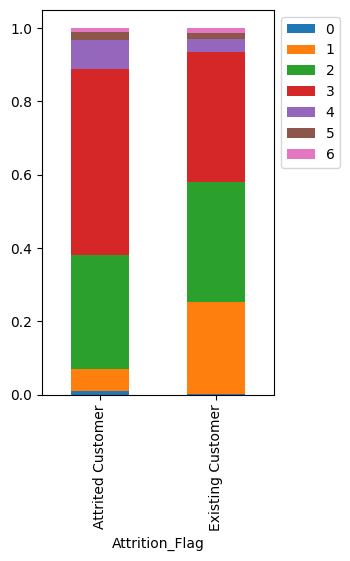

In [21]:
# Q5. How does the number of months a customer was inactive in the last 12 months (Months_Inactive_12_mon) vary by the customer's account status (Attrition_Flag)?

#distribution_plot_wrt_target(pd_card, 'Attrition_Flag', 'Months_Inactive_12_mon')

stacked_barplot(pd_card, 'Attrition_Flag', 'Months_Inactive_12_mon')


### Observations

1. It looks like existing Customers that are havign 3 months on Inativity are the highest Attrited Customer.
2. This could be one of teh patraters we might ha to observe how well it influences the classification Importance.

## Data Pre-processing

1. In this section we will prepare the data for classification analysis.
2. We will also build a Correlation Heatmap to address the above questionon features having Correlation using EDA.
3. We will try to buil Heatmap to see the variables that influences attrition.

In [22]:
# Check for Null & NaN

pd_card.isna().sum()

CLIENTNUM                      0
Attrition_Flag                 0
Customer_Age                   0
Gender                         0
Dependent_count                0
Education_Level             1519
Marital_Status               749
Income_Category                0
Card_Category                  0
Months_on_book                 0
Total_Relationship_Count       0
Months_Inactive_12_mon         0
Contacts_Count_12_mon          0
Credit_Limit                   0
Total_Revolving_Bal            0
Avg_Open_To_Buy                0
Total_Amt_Chng_Q4_Q1           0
Total_Trans_Amt                0
Total_Trans_Ct                 0
Total_Ct_Chng_Q4_Q1            0
Avg_Utilization_Ratio          0
dtype: int64

### Observation

1. Education we see 1519 rows that have N/A.
2. Sicne these are discreent values we cant take any Mean or Mode.
3. So the bestt bet is to reove the N/A. But removing 1519 rows can impact the Analysis.
4. So what we do is:
  - First you impute N/A to "NotApplicable" string.
  - Next we do OneHotEncoding.
  - Next we drop "NotApplicable" Column.
5. In this way rest of features will be preserved for that rows but the influence of N/A will be removed.

6. MaritalStatus also has the same problem of N/A and we will apply 'NotApplicable' to this as well

7. Also one observation in Income Catgory where we have 'abc' occuring that need to be changed to 'NotApplicable'. This will also be removed using one-hot encoding.

In [23]:
# Creating a temorary copy of dataframe for Features Engineering & Imputation.

pd_card1 = pd_card.copy()

In [24]:
# Imputing Education &  N/A with "NotApplicable"

pd_card1.fillna(value={'Education_Level': 'NotApplicable', 'Marital_Status': 'NotApplicable'}, inplace=True)
pd_card1.replace(to_replace='abc', value={'Income_Category': 'NotApplicable'}, inplace=True)

In [25]:
# Imputing 'Income_Category' for Encoding later

pd_card1['Income_Category'].replace({'$120K +': 'Greater_120K', '$80K - $120K': '80K_120K', '$60K - $80K': '60K_80K', '$40K - $60K': '40K_60K', 'Less than $40K': 'Less_40K'}, inplace=True)

In [26]:
# Impute 'Gender' Category with Binary Value
# Male = 1, Female = 0

pd_card1['Gender'].replace({'M': 1, 'F': 0}, inplace=True)

# Impute 'Attrition_Flag' Category with Binary Value
# Male = 1, Female = 0

pd_card1['Attrition_Flag'].replace({'Attrited Customer': 0, 'Existing Customer': 1}, inplace=True)

In [27]:
# Executing OneHotEncoding on  - Education_Level, Marital_Status, Income_Category, Card_Category

pd_card1 = pd.get_dummies(pd_card1, columns=['Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category'], dtype='int64')
pd_card1.columns

Index(['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Gender',
       'Dependent_count', 'Months_on_book', 'Total_Relationship_Count',
       'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit',
       'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1',
       'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1',
       'Avg_Utilization_Ratio', 'Education_Level_College',
       'Education_Level_Doctorate', 'Education_Level_Graduate',
       'Education_Level_High School', 'Education_Level_NotApplicable',
       'Education_Level_Post-Graduate', 'Education_Level_Uneducated',
       'Marital_Status_Divorced', 'Marital_Status_Married',
       'Marital_Status_NotApplicable', 'Marital_Status_Single',
       'Income_Category_40K_60K', 'Income_Category_60K_80K',
       'Income_Category_80K_120K', 'Income_Category_Greater_120K',
       'Income_Category_Less_40K', 'Income_Category_NotApplicable',
       'Card_Category_Blue', 'Card_Category_Gold', 'Card_Category_

In [28]:
# Droping following Columns
# - CLIENTNUM
# - 'NotApplicable' Columns in - Income_Category, Education_Level, Marital_Status

pd_card1.drop(['CLIENTNUM', 'Education_Level_NotApplicable', 'Marital_Status_NotApplicable', 'Income_Category_NotApplicable'], axis=1, inplace=True)


In [29]:
# Visualising Data after Data-prep & Encoding

pd_card = pd_card1.copy()
pd_card.head(10)

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,...,Marital_Status_Single,Income_Category_40K_60K,Income_Category_60K_80K,Income_Category_80K_120K,Income_Category_Greater_120K,Income_Category_Less_40K,Card_Category_Blue,Card_Category_Gold,Card_Category_Platinum,Card_Category_Silver
0,1,45,1,3,39,5,1,3,12691.0,777,...,0,0,1,0,0,0,1,0,0,0
1,1,49,0,5,44,6,1,2,8256.0,864,...,1,0,0,0,0,1,1,0,0,0
2,1,51,1,3,36,4,1,0,3418.0,0,...,0,0,0,1,0,0,1,0,0,0
3,1,40,0,4,34,3,4,1,3313.0,2517,...,0,0,0,0,0,1,1,0,0,0
4,1,40,1,3,21,5,1,0,4716.0,0,...,0,0,1,0,0,0,1,0,0,0
5,1,44,1,2,36,3,1,2,4010.0,1247,...,0,1,0,0,0,0,1,0,0,0
6,1,51,1,4,46,6,1,3,34516.0,2264,...,0,0,0,0,1,0,0,1,0,0
7,1,32,1,0,27,2,2,2,29081.0,1396,...,0,0,1,0,0,0,0,0,0,1
8,1,37,1,3,36,5,2,0,22352.0,2517,...,1,0,1,0,0,0,1,0,0,0
9,1,48,1,2,36,6,3,3,11656.0,1677,...,1,0,0,1,0,0,1,0,0,0


In [30]:
# Getting Info on the new Dataset after Data-prep & Encoding.

pd_card.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 34 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Attrition_Flag                 10127 non-null  int64  
 1   Customer_Age                   10127 non-null  int64  
 2   Gender                         10127 non-null  int64  
 3   Dependent_count                10127 non-null  int64  
 4   Months_on_book                 10127 non-null  int64  
 5   Total_Relationship_Count       10127 non-null  int64  
 6   Months_Inactive_12_mon         10127 non-null  int64  
 7   Contacts_Count_12_mon          10127 non-null  int64  
 8   Credit_Limit                   10127 non-null  float64
 9   Total_Revolving_Bal            10127 non-null  int64  
 10  Avg_Open_To_Buy                10127 non-null  float64
 11  Total_Amt_Chng_Q4_Q1           10127 non-null  float64
 12  Total_Trans_Amt                10127 non-null 

### Observations

1. We Prepared the data as follows -
  - Removed N/A and NaN Values.
  - Unwanted strings like 'abc' was converted on 'NotApplicable'.
  - OnHotEncoding was done on certain Categorical Columns.
  - 'NotApplicable' Columns were removed.
  - ClientID columns were also removed.
  - Income Categories were cleaned and prepared.

2. There are few other Category Columns that has -
  - Sequential data - This has not been treated.
  - Binary Columns (Marital Status & Attrition_Flag) were changed Numeric Value of 1s & 0s
  - This was purely done due to the fact that we can do correlation graphs like Hatmaps since DecisionTree can handle bynary categorical values.

3. After Model Prep following are the targets:
  - Existing Customers = 1
  - Attrited Customers = 0

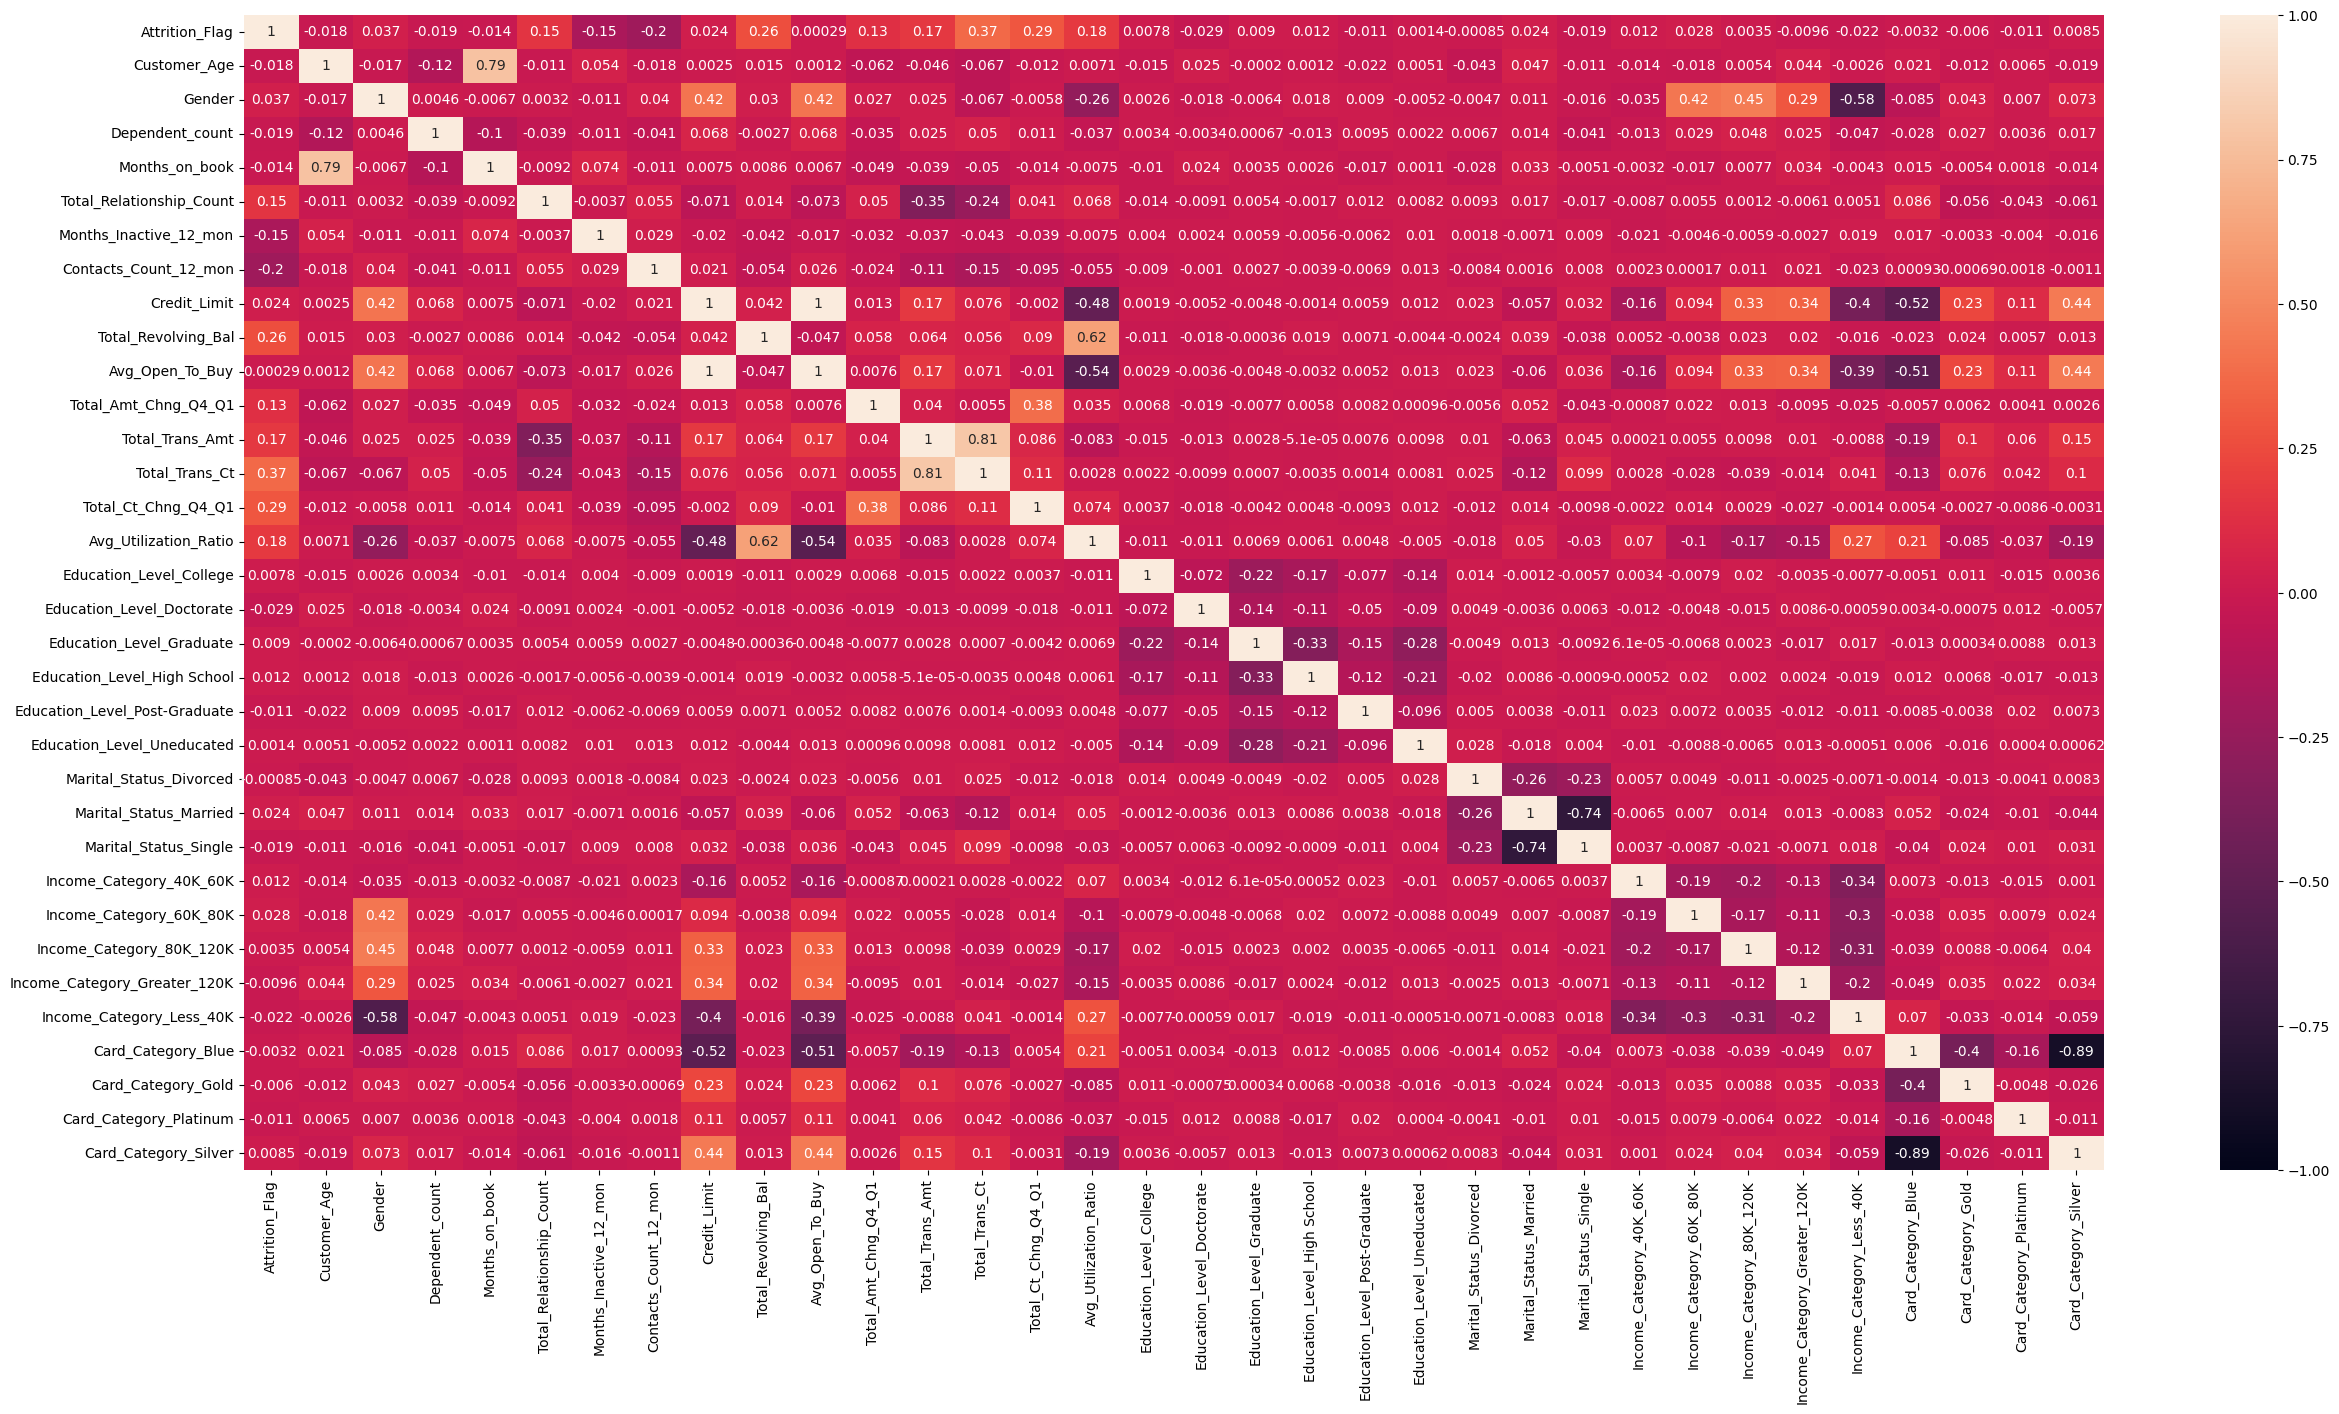

In [31]:
# Building Bi-Variate Visualization - Heatmap
# Plot Heatmap to see Correlation

plt.figure(figsize=(30, 15))
sns.heatmap(data=pd_card.corr(), vmin=-1, vmax=1, cbar=True, annot=True)
plt.show();

### Obsrvations

1. Attrition_Flah has hog Correlation with:
  - Total_Trans_Ct
  - Total_Trans_Amt
  - Total_Amt_Chng_Q4_Q1
  - Total_Ct_Chng_Q4_Q1

2. We will see if these shows up in Model Analysis.

## Model Building

### Model evaluation criterion

#### **Success Criteria**

1. Find influencing Attributes that helps Customer Retention / of reduce Attrition.

2. Confusion Metrics
  - TP = Existing Stay (Predict) / Customer Stay (Actual)
  - FP = Customer Stay (Predict) / Customer DONOT Stay (Actual)
  - FN = Customer DONOT Stay (Predict) / Customer Stay (Actual)
  - TN = Customer DONOT Stay (Predict) / Customer DONOT Stay (Actual)

3. Success Criteria =
  - Improve 'Precision' by reducing FP.
  - Improving 'Recall'  by reducting FN since, if our Model could predict correctly who will Stay or leave based on parameters, TP will automatically increase.
  - Both these scenarios are benificial to bank.

4. We will target to maximise Recall & Precision in our Decision Metrix.

In [32]:
# Creating Training & Testing Data-set

y = pd_card['Attrition_Flag']
X = pd_card.drop(['Attrition_Flag'], axis=1)

X_temp, X_eval, y_temp, y_eval = train_test_split(X, y, train_size=0.8, random_state=1, stratify=y)
X_train, X_test, y_train, y_test = train_test_split(X_temp, y_temp, train_size=0.7, random_state=1)

y_train.value_counts()

Attrition_Flag
1    4758
0     912
Name: count, dtype: int64

### Model Building with original data

In [33]:
# Creating Base Decision Matrix
# NO Pruning is done.

decision_tree = DecisionTreeClassifier(criterion='gini', random_state=1)
decision_tree.fit(X_train, y_train)

#Calculating Accuracy
print('Accuracy Base Score Training:', decision_tree.score(X_train, y_train))
print('Accuracy Base Score Testing:', decision_tree.score(X_test, y_test))

# Build Predic Variables
y_predict_train = decision_tree.predict(X_train)
y_predict_test = decision_tree.predict(X_test)

#Calculate Precision
print('Precision Base Score Training:', precision_score(y_train, y_predict_train))
print('Precision Base Score Testing:', precision_score(y_test, y_predict_test))

#Calculate Recall Score
print('Recall Base Score Training:', recall_score(y_train, y_predict_train))
print('Recall Base Score Testing:', recall_score(y_test, y_predict_test))


Accuracy Base Score Training: 1.0
Accuracy Base Score Testing: 0.9370629370629371
Precision Base Score Training: 1.0
Precision Base Score Testing: 0.9604878048780487
Recall Base Score Training: 1.0
Recall Base Score Testing: 0.9647231749142577


Feature Importance
                               Importance
Total_Trans_Ct                   0.289287
Total_Revolving_Bal              0.191709
Total_Trans_Amt                  0.148843
Total_Ct_Chng_Q4_Q1              0.089846
Total_Relationship_Count         0.088187
Total_Amt_Chng_Q4_Q1             0.042246
Customer_Age                     0.038169
Avg_Open_To_Buy                  0.023433
Months_Inactive_12_mon           0.017139
Credit_Limit                     0.014570
Contacts_Count_12_mon            0.011533
Months_on_book                   0.008571
Avg_Utilization_Ratio            0.005201
Marital_Status_Married           0.005136
Gender                           0.003618
Income_Category_60K_80K          0.003217
Income_Category_Less_40K         0.003088
Dependent_count                  0.002926
Education_Level_Uneducated       0.002077
Education_Level_High School      0.001851
Education_Level_College          0.001742
Card_Category_Platinum           0.001288
Education_Level

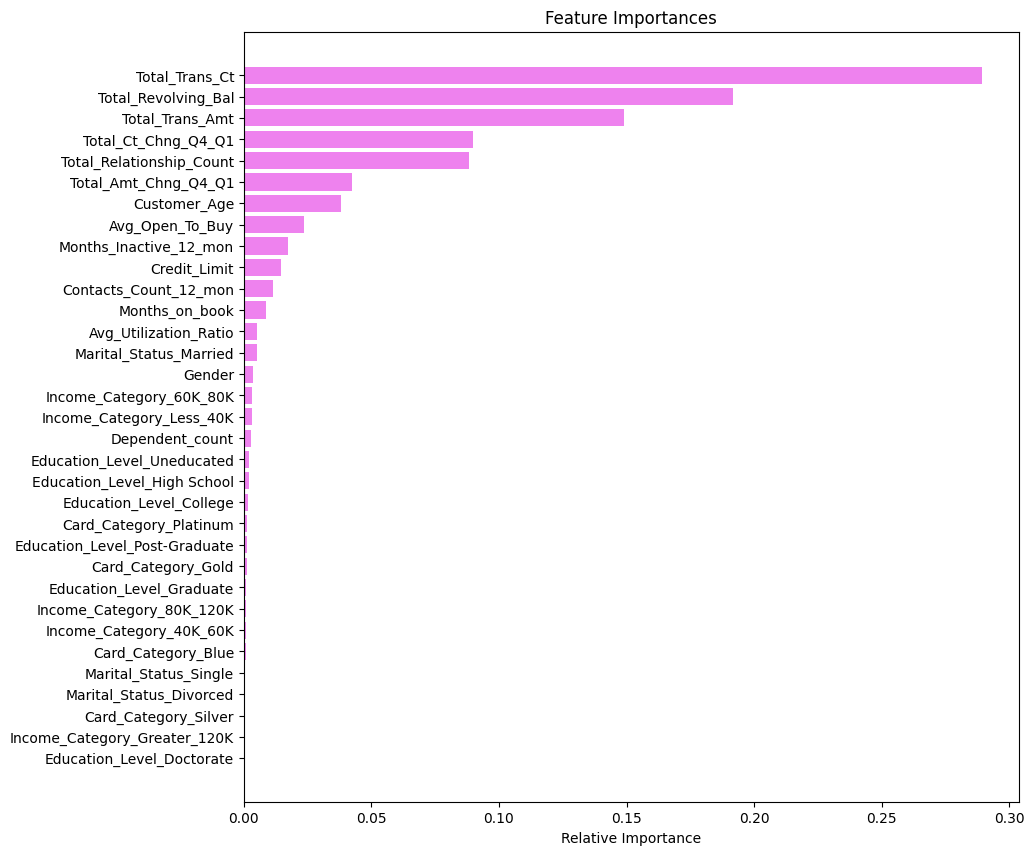

In [34]:
# Creating Random Classifier Base Feature Matrix

decision_tree = decision_tree

feature_importance_df = pd.DataFrame(decision_tree.feature_importances_, columns=['Importance'], index=X_train.columns).sort_values(by='Importance', ascending=False)
print('Feature Importance')
print(feature_importance_df)

feature_names = decision_tree.feature_names_in_
feature_importance = decision_tree.feature_importances_
indices = np.argsort(feature_importance)

plt.figure(figsize=(10,10))
plt.title('Feature Importances')
plt.barh(range(len(indices)), feature_importance[indices], color='violet', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show();

### Observations

1. Accuracy, Recall and Precision are all '1' for Training Data.
2. In Testing the Accuracy is lower than Precision and Recall.
3. Precision and Recall are close to 1 for Testing.
4. This all suggest over-fitting. Later we will do Hyper-Parameter tuning and  see what if the numbers change.

Imporant Features:
  - Total_Trans_Ct
  - Total_Trans_Amt
  - Total_Revolving_Bal


In [35]:
# Creating Base Bagging Classifier Matrix

bagging_classifier = BaggingClassifier(random_state=1)
bagging_classifier.fit(X_train, y_train)

#Calculating Accuracy
print('Accuracy Base Score Training:', bagging_classifier.score(X_train, y_train))
print('Accuracy Base Score Testing:', bagging_classifier.score(X_test, y_test))

# Build Predic Variables
y_predict_train = bagging_classifier.predict(X_train)
y_predict_test = bagging_classifier.predict(X_test)

#Calculate Precision
print('Precision Base Score Training:', precision_score(y_train, y_predict_train))
print('Precision Base Score Testing:', precision_score(y_test, y_predict_test))

#Calculate Recall Score
print('Recall Base Score Training:', recall_score(y_train, y_predict_train))
print('Recall Base Score Testing:', recall_score(y_test, y_predict_test))


Accuracy Base Score Training: 0.9966490299823633
Accuracy Base Score Testing: 0.9559851912793089
Precision Base Score Training: 0.9987371079772679
Precision Base Score Testing: 0.9685077519379846
Recall Base Score Training: 0.9972677595628415
Recall Base Score Testing: 0.979421852033317


### Observations

1. Accuracy, Recall and Precision have all reduced to 0.99 for Traning.
2. In Testing Accuracy, Recall, Precision has increased slightly but teh gap between Training & Testing has reduced.
3. This all suggest over-fitting. Later we will do Hyper-Parameter tuning and  see what if the numbers change.

In [36]:
# Creating Base RandomForest Classifier Matrix

random_classifier = RandomForestClassifier(random_state=1)
random_classifier.fit(X_train, y_train)

#Calculating Accuracy
print('Accuracy Base Score Training:', random_classifier.score(X_train, y_train))
print('Accuracy Base Score Testing:', random_classifier.score(X_test, y_test))

# Build Predic Variables
y_predict_train = random_classifier.predict(X_train)
y_predict_test = random_classifier.predict(X_test)

#Calculate Precision
print('Precision Base Score Training:', precision_score(y_train, y_predict_train))
print('Precision Base Score Testing:', precision_score(y_test, y_predict_test))

#Calculate Recall Score
print('Recall Base Score Training:', recall_score(y_train, y_predict_train))
print('Recall Base Score Testing:', recall_score(y_test, y_predict_test))

Accuracy Base Score Training: 1.0
Accuracy Base Score Testing: 0.9531057178116001
Precision Base Score Training: 1.0
Precision Base Score Testing: 0.9572852396772663
Recall Base Score Training: 1.0
Recall Base Score Testing: 0.9882410583047526


Feature Importance
                               Importance
Total_Trans_Amt                  0.171019
Total_Trans_Ct                   0.166087
Total_Ct_Chng_Q4_Q1              0.108078
Total_Revolving_Bal              0.094319
Total_Amt_Chng_Q4_Q1             0.065468
Avg_Utilization_Ratio            0.062569
Total_Relationship_Count         0.058197
Credit_Limit                     0.039076
Avg_Open_To_Buy                  0.035100
Customer_Age                     0.032219
Contacts_Count_12_mon            0.028597
Months_on_book                   0.028577
Months_Inactive_12_mon           0.027976
Dependent_count                  0.016094
Gender                           0.009204
Marital_Status_Married           0.007574
Marital_Status_Single            0.005670
Income_Category_Less_40K         0.005054
Education_Level_Graduate         0.004436
Education_Level_High School      0.003765
Income_Category_60K_80K          0.003653
Income_Category_80K_120K         0.003490
Education_Level

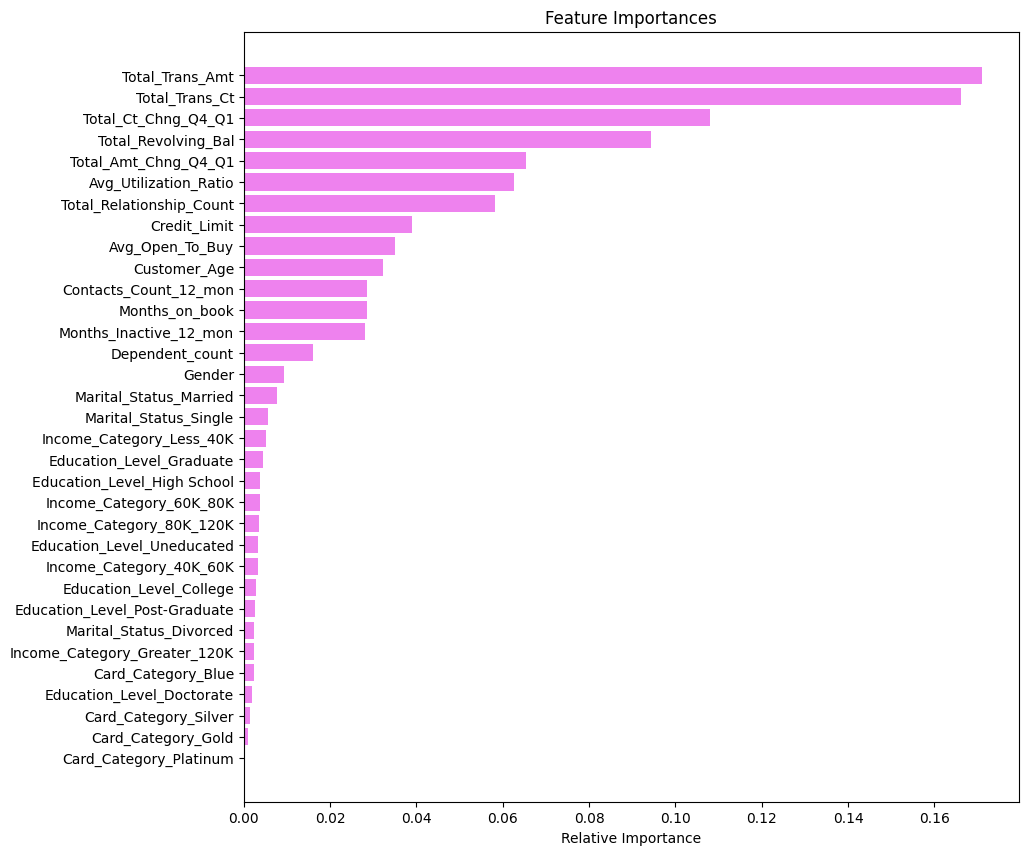

In [37]:
# Creating Random Classifier Base Feature Matrix

decision_tree = random_classifier

feature_importance_df = pd.DataFrame(decision_tree.feature_importances_, columns=['Importance'], index=X_train.columns).sort_values(by='Importance', ascending=False)
print('Feature Importance')
print(feature_importance_df)

feature_names = decision_tree.feature_names_in_
feature_importance = decision_tree.feature_importances_
indices = np.argsort(feature_importance)

plt.figure(figsize=(10,10))
plt.title('Feature Importances')
plt.barh(range(len(indices)), feature_importance[indices], color='violet', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show();

### Observations

1. Accuracy, Recall and Precision are all '1' for Training Data.
2. In Testing the Accuracy & Precision reduced by few points.
3. Recall has steadly increased to 0.98.
4. This all suggest over-fitting. Later we will do Hyper-Parameter tuning and  see what if the numbers change.

Imporant Features:
  - Total_Trans_Amt
  - Total_Trans_Ct
  - Total_Ct_Chng_Q4_Q1
  - Total_Revolving_Bal
      - Feature Order changes and new feature got introduced in top 3.

In [38]:
# Creating Base AdaBoosting Classifier

ada_classifier = AdaBoostClassifier(random_state=1)
ada_classifier.fit(X_train, y_train)

#Calculating Accuracy
print('Accuracy Base Score Training:', ada_classifier.score(X_train, y_train))
print('Accuracy Base Score Testing:', ada_classifier.score(X_test, y_test))

# Build Predic Variables
y_predict_train = ada_classifier.predict(X_train)
y_predict_test = ada_classifier.predict(X_test)

#Calculate Precision
print('Precision Base Score Training:', precision_score(y_train, y_predict_train))
print('Precision Base Score Testing:', precision_score(y_test, y_predict_test))

#Calculate Recall Score
print('Recall Base Score Training:', recall_score(y_train, y_predict_train))
print('Recall Base Score Testing:', recall_score(y_test, y_predict_test))

Accuracy Base Score Training: 0.9620811287477954
Accuracy Base Score Testing: 0.958041958041958
Precision Base Score Training: 0.9743161411568177
Precision Base Score Testing: 0.9658817876021144
Recall Base Score Training: 0.9806641445985709
Recall Base Score Testing: 0.984811366976972


Feature Importance
                               Importance
Total_Trans_Amt                      0.40
Total_Trans_Ct                       0.18
Total_Amt_Chng_Q4_Q1                 0.08
Contacts_Count_12_mon                0.06
Total_Ct_Chng_Q4_Q1                  0.06
Total_Revolving_Bal                  0.06
Customer_Age                         0.04
Total_Relationship_Count             0.04
Months_Inactive_12_mon               0.02
Marital_Status_Married               0.02
Avg_Utilization_Ratio                0.02
Gender                               0.02
Card_Category_Blue                   0.00
Income_Category_Less_40K             0.00
Card_Category_Gold                   0.00
Card_Category_Platinum               0.00
Income_Category_Greater_120K         0.00
Income_Category_80K_120K             0.00
Income_Category_60K_80K              0.00
Income_Category_40K_60K              0.00
Marital_Status_Single                0.00
Education_Level_Doctorate            0.00
Marital_Status_

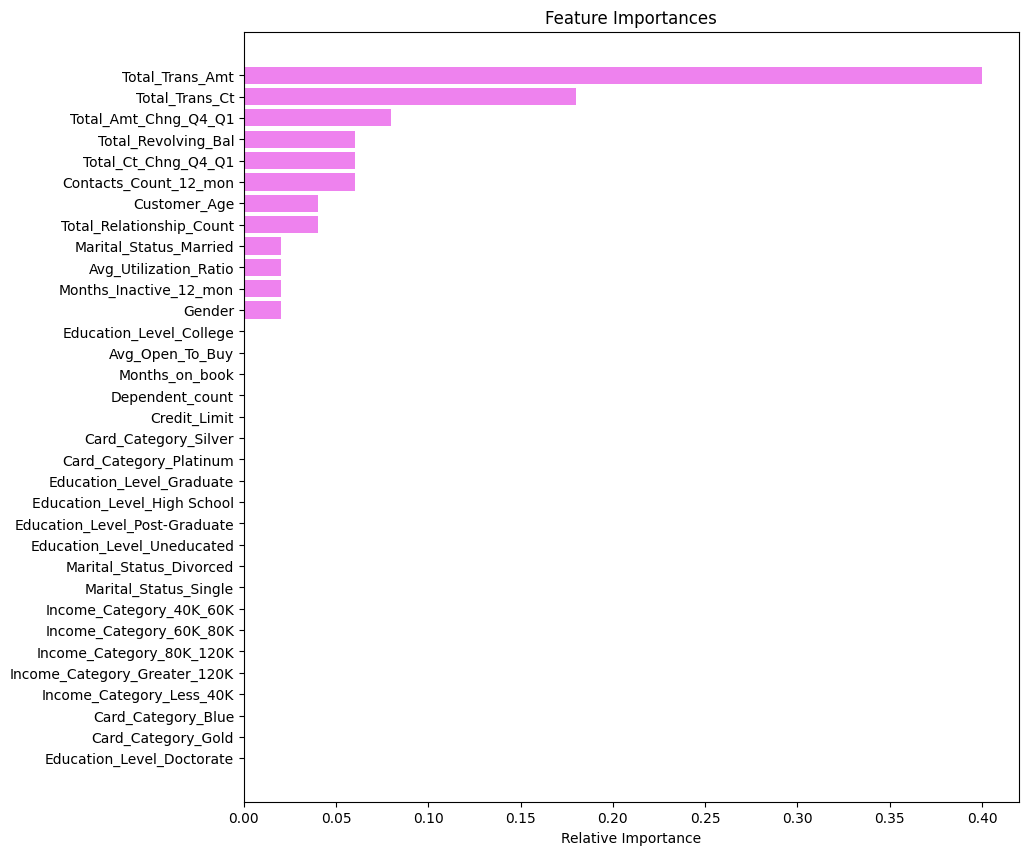

In [39]:
# Creating AdaBoost Base Feature Matrix

decision_tree = ada_classifier

feature_importance_df = pd.DataFrame(decision_tree.feature_importances_, columns=['Importance'], index=X_train.columns).sort_values(by='Importance', ascending=False)
print('Feature Importance')
print(feature_importance_df)

feature_names = decision_tree.feature_names_in_
feature_importance = decision_tree.feature_importances_
indices = np.argsort(feature_importance)

plt.figure(figsize=(10,10))
plt.title('Feature Importances')
plt.barh(range(len(indices)), feature_importance[indices], color='violet', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show();

### Observations

1. Accuracy, Recall and Precision are all ~0.96, ~0.97, ~0.98 for Training Data.
2. In Testing Accuracy, Recall, Precision is also very very similar ~0.96, ~0.97, ~0.98.
4. We will see how the Hyper-Parameter tuning and influence tehse numbers.
%. The current result suggest that the Predictability in Testing is same as using Trainind data.

Imporant Features:
  - Total_Trans_Amt
  - Total_Trans_Ct
  - Total_Ct_Chng_Q4_Q1
      - Feature Order remained the same.
      - Relative importance values of these metrics has changed.

In [40]:
# Create GradientBoost Base Model

gboost_classifier = GradientBoostingClassifier(random_state=1)
gboost_classifier.fit(X_train, y_train)

#Calculating Accuracy
print('Accuracy Base Score Training:', gboost_classifier.score(X_train, y_train))
print('Accuracy Base Score Testing:', gboost_classifier.score(X_test, y_test))

# Build Predic Variables
y_predict_train = gboost_classifier.predict(X_train)
y_predict_test = gboost_classifier.predict(X_test)

#Calculate Precision
print('Precision Base Score Training:', precision_score(y_train, y_predict_train))
print('Precision Base Score Testing:', precision_score(y_test, y_predict_test))

#Calculate Recall Score
print('Recall Base Score Training:', recall_score(y_train, y_predict_train))
print('Recall Base Score Testing:', recall_score(y_test, y_predict_test))


Accuracy Base Score Training: 0.9800705467372134
Accuracy Base Score Testing: 0.9646236116824353
Precision Base Score Training: 0.9827478694658075
Precision Base Score Testing: 0.9697260932244114
Recall Base Score Training: 0.9936948297604036
Recall Base Score Testing: 0.9887310142087212


Feature Importance
                               Importance
Total_Trans_Ct                   0.353621
Total_Trans_Amt                  0.201127
Total_Revolving_Bal              0.180860
Total_Ct_Chng_Q4_Q1              0.105763
Total_Relationship_Count         0.080498
Total_Amt_Chng_Q4_Q1             0.025050
Contacts_Count_12_mon            0.016107
Customer_Age                     0.013836
Months_Inactive_12_mon           0.013466
Avg_Open_To_Buy                  0.003328
Credit_Limit                     0.001199
Months_on_book                   0.001160
Marital_Status_Married           0.001070
Gender                           0.001030
Card_Category_Platinum           0.000765
Card_Category_Gold               0.000441
Income_Category_60K_80K          0.000333
Dependent_count                  0.000178
Avg_Utilization_Ratio            0.000121
Marital_Status_Single            0.000025
Income_Category_Greater_120K     0.000023
Card_Category_Blue               0.000000
Income_Category

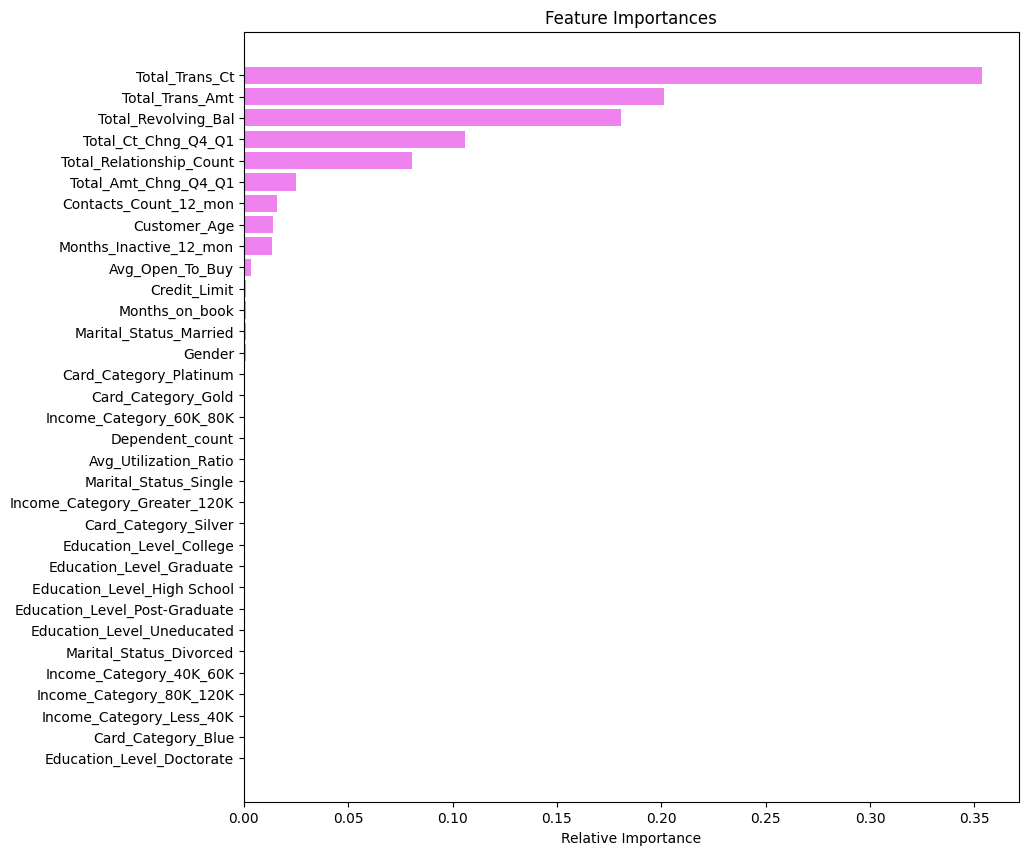

In [41]:
# Creating Gradient Boost Base Feature Matrix

decision_tree = gboost_classifier

feature_importance_df = pd.DataFrame(decision_tree.feature_importances_, columns=['Importance'], index=X_train.columns).sort_values(by='Importance', ascending=False)
print('Feature Importance')
print(feature_importance_df)

feature_names = decision_tree.feature_names_in_
feature_importance = decision_tree.feature_importances_
indices = np.argsort(feature_importance)

plt.figure(figsize=(10,10))
plt.title('Feature Importances')
plt.barh(range(len(indices)), feature_importance[indices], color='violet', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show();

### Observations

1. Accuracy, Recall and Precision have sligtly increased for Training Data.
2. In Testing Accuracy, Recall, Precision is also very very similar ~0.96, ~0.97, ~0.98.
4. We will see how the Hyper-Parameter tuning and influence tehse numbers.
%. The current result suggest that the Predictability in Testing is same as using Trainind data.

Imporant Features:
  - Total_Trans_Amt
  - Total_Trans_Ct
  - Total_Revolving_Bal
      - Feature Order has changed
      - Total_Ct_Chng_Q4_Q1 has been moved out of top three.

### Model Building with Oversampled data

In [42]:
#Creating Over Sampling Data
# Synthetic Minority Over Sampling Technique
sm = SMOTE(sampling_strategy=1, k_neighbors=5, random_state=1)
X_train_over, y_train_over = sm.fit_resample(X_train, y_train)

y_train_over.value_counts()

Attrition_Flag
1    4758
0    4758
Name: count, dtype: int64

### Observations

1. We can see the '0' Class is over Sampled

In [43]:
# Creating Base Decision Matrix - Over Sampled Dataset
# NO Pruning is done.

decision_tree_ov = DecisionTreeClassifier(criterion='gini', random_state=1)
decision_tree_ov.fit(X_train_over, y_train_over)

#Calculating Accuracy
print('Accuracy Base Score Training:', decision_tree_ov.score(X_train_over, y_train_over))
print('Accuracy Base Score Testing:', decision_tree_ov.score(X_test, y_test))

# Build Predic Variables
y_predict_train = decision_tree_ov.predict(X_train_over)
y_predict_test = decision_tree_ov.predict(X_test)

#Calculate Precision
print('Precision Base Score Training:', precision_score(y_train_over, y_predict_train))
print('Precision Base Score Testing:', precision_score(y_test, y_predict_test))

#Calculate Recall Score
print('Recall Base Score Training:', recall_score(y_train_over, y_predict_train))
print('Recall Base Score Testing:', recall_score(y_test, y_predict_test))

Accuracy Base Score Training: 1.0
Accuracy Base Score Testing: 0.9271904566022213
Precision Base Score Training: 1.0
Precision Base Score Testing: 0.9674022066198595
Recall Base Score Training: 1.0
Recall Base Score Testing: 0.945124938755512


Feature Importance
                               Importance
Total_Trans_Ct                   0.472388
Total_Trans_Amt                  0.152583
Total_Revolving_Bal              0.094507
Total_Relationship_Count         0.069469
Total_Ct_Chng_Q4_Q1              0.066794
Total_Amt_Chng_Q4_Q1             0.025598
Credit_Limit                     0.016702
Customer_Age                     0.015578
Avg_Open_To_Buy                  0.012897
Marital_Status_Married           0.010848
Gender                           0.006110
Months_on_book                   0.005749
Contacts_Count_12_mon            0.005069
Months_Inactive_12_mon           0.004928
Marital_Status_Single            0.004709
Avg_Utilization_Ratio            0.004263
Marital_Status_Divorced          0.004232
Income_Category_80K_120K         0.003765
Income_Category_40K_60K          0.003060
Education_Level_High School      0.002855
Dependent_count                  0.002634
Income_Category_60K_80K          0.002591
Education_Level

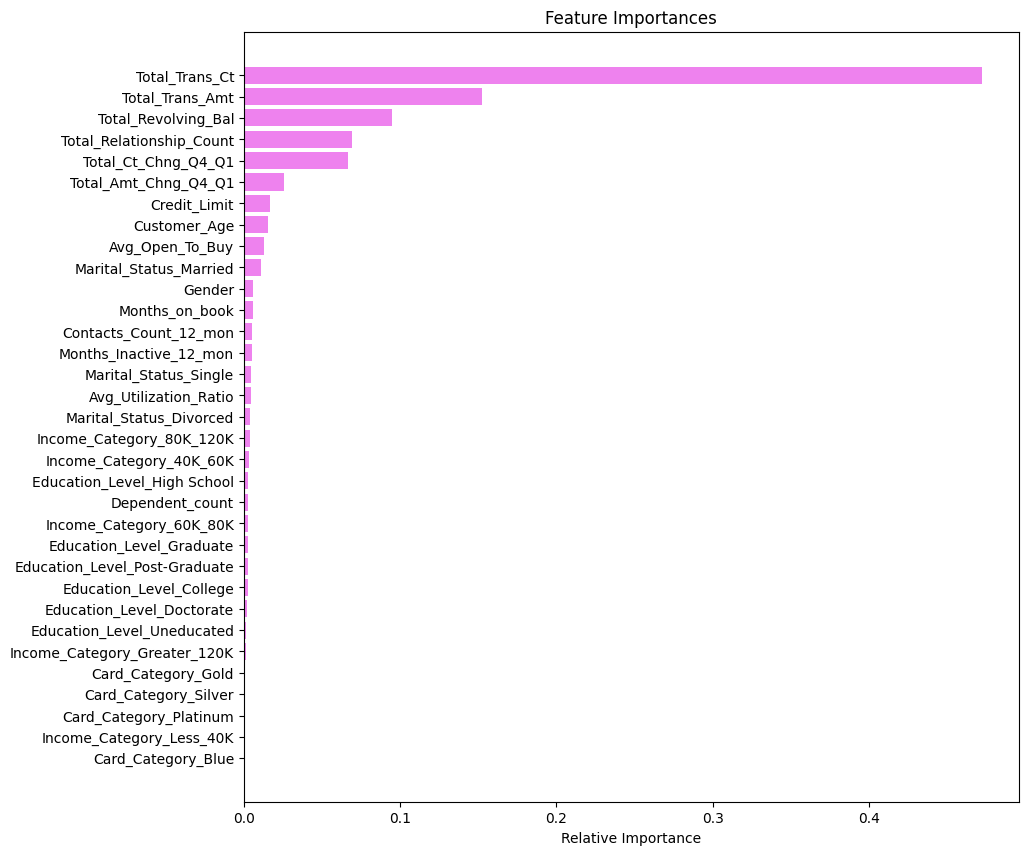

In [44]:
# Creating DecisionTree Base Feature Matrix - Over Sampled Data

decision_tree = decision_tree_ov

feature_importance_df = pd.DataFrame(decision_tree.feature_importances_, columns=['Importance'], index=X_train.columns).sort_values(by='Importance', ascending=False)
print('Feature Importance')
print(feature_importance_df)

feature_names = decision_tree.feature_names_in_
feature_importance = decision_tree.feature_importances_
indices = np.argsort(feature_importance)

plt.figure(figsize=(10,10))
plt.title('Feature Importances')
plt.barh(range(len(indices)), feature_importance[indices], color='violet', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show();

### Observations

1. Accuracy, Recall and Precision are all '1' for Training Data.
2. In Testing the Accuracy is lower than Precision and Recall.
3. Precision is hgher than Recall. 0.96 & 0.94 respectively.
4. We will check for Over-Fitting when we do Hyper Parameter Tuning.

Imporant Features:
  - Total_Trans_Ct
  - Total_Trans_Amt
  - Total_Revolving_Bal
    - There is a change in the order of feature importance.


In [45]:
# Creating Base Bagging Classifier Matrix - Over-Sampled Dataset

bagging_classifier_ov = BaggingClassifier(random_state=1)
bagging_classifier_ov.fit(X_train_over, y_train_over)

#Calculating Accuracy
print('Accuracy Base Score Training:', bagging_classifier_ov.score(X_train_over, y_train_over))
print('Accuracy Base Score Testing:', bagging_classifier_ov.score(X_test, y_test))

# Build Predic Variables
y_predict_train = bagging_classifier_ov.predict(X_train_over)
y_predict_test = bagging_classifier_ov.predict(X_test)

#Calculate Precision
print('Precision Base Score Training:', precision_score(y_train_over, y_predict_train))
print('Precision Base Score Testing:', precision_score(y_test, y_predict_test))

#Calculate Recall Score
print('Recall Base Score Training:', recall_score(y_train_over, y_predict_train))
print('Recall Base Score Testing:', recall_score(y_test, y_predict_test))


Accuracy Base Score Training: 0.9974779319041615
Accuracy Base Score Testing: 0.9411764705882353
Precision Base Score Training: 0.9997888513513513
Precision Base Score Testing: 0.9759277833500501
Recall Base Score Training: 0.9951660361496427
Recall Base Score Testing: 0.953454189122979


### Observations

1. Accuracy, Recall and Precision have all reduced to 0.99 for Traning.
2. In Testing Accuracy, Recall, Precision has increased slightly but teh gap between Training & Testing has reduced.
3. Increase is less than Baggign Classifier using Base Dataset.
3. Later we will do Hyper-Parameter tuning and  see what if the numbers change.

In [46]:
# Creating base RandomForest Classifier Matrix - Over-Sampled Dataset

random_classifier_ov = RandomForestClassifier(random_state=1)
random_classifier_ov.fit(X_train_over, y_train_over)

#Calculating Accuracy
print('Accuracy Base Score Training:', random_classifier_ov.score(X_train_over, y_train_over))
print('Accuracy Base Score Testing:', random_classifier_ov.score(X_test, y_test))

# Build Predic Variables
y_predict_train = random_classifier_ov.predict(X_train_over)
y_predict_test = random_classifier_ov.predict(X_test)

#Calculate Precision
print('Precision Base Score Training:', precision_score(y_train_over, y_predict_train))
print('Precision Base Score Testing:', precision_score(y_test, y_predict_test))

#Calculate Recall Score
print('Recall Base Score Training:', recall_score(y_train_over, y_predict_train))
print('Recall Base Score Testing:', recall_score(y_test, y_predict_test))

Accuracy Base Score Training: 1.0
Accuracy Base Score Testing: 0.9473467708761827
Precision Base Score Training: 1.0
Precision Base Score Testing: 0.9677261613691932
Recall Base Score Training: 1.0
Recall Base Score Testing: 0.9696227339539442


Feature Importance
                               Importance
Total_Trans_Ct                   0.236834
Total_Trans_Amt                  0.179589
Total_Ct_Chng_Q4_Q1              0.094150
Total_Revolving_Bal              0.080763
Avg_Utilization_Ratio            0.053809
Total_Relationship_Count         0.050239
Total_Amt_Chng_Q4_Q1             0.045664
Credit_Limit                     0.029091
Avg_Open_To_Buy                  0.027030
Marital_Status_Married           0.025771
Customer_Age                     0.023545
Gender                           0.019159
Months_on_book                   0.017311
Months_Inactive_12_mon           0.015149
Contacts_Count_12_mon            0.015142
Marital_Status_Single            0.013580
Dependent_count                  0.009761
Education_Level_Graduate         0.009407
Education_Level_High School      0.008623
Income_Category_Less_40K         0.006033
Education_Level_Uneducated       0.005882
Income_Category_60K_80K          0.005468
Income_Category

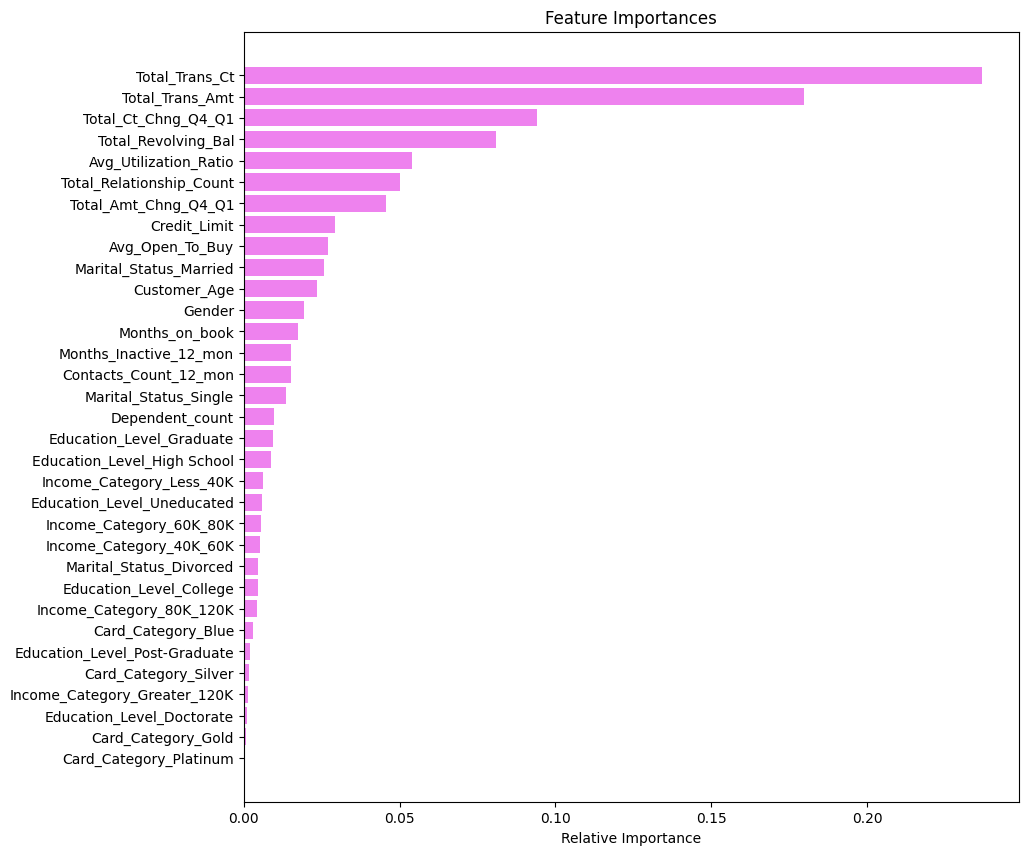

In [47]:
# Creating RandomForest Base Feature Matrix using Over-Sampled Data

decision_tree = random_classifier_ov

feature_importance_df = pd.DataFrame(decision_tree.feature_importances_, columns=['Importance'], index=X_train.columns).sort_values(by='Importance', ascending=False)
print('Feature Importance')
print(feature_importance_df)

feature_names = decision_tree.feature_names_in_
feature_importance = decision_tree.feature_importances_
indices = np.argsort(feature_importance)

plt.figure(figsize=(10,10))
plt.title('Feature Importances')
plt.barh(range(len(indices)), feature_importance[indices], color='violet', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show();

### Observations

1. Accuracy, Recall and Precision are all '1' for Training Data.
2. In Testing the Accuracy & Precision reduced by few points.
3. Recall has steadly increased to 0.97.
4. This all suggest over-fitting. Later we will do Hyper-Parameter tuning and  see what if the numbers change.

Imporant Features:
  - Total_Trans_Ct
  - Total_Trans_Amt
  - Total_Ct_Change_Q4_Q1

In [48]:
# Creating Base AdaBoosting Classifier - Over Sampled Dataset

ada_classifier_ov = AdaBoostClassifier(random_state=1)
ada_classifier_ov.fit(X_train_over, y_train_over)

#Calculating Accuracy
print('Accuracy Base Score Training:', ada_classifier_ov.score(X_train_over, y_train_over))
print('Accuracy Base Score Testing:', ada_classifier_ov.score(X_test, y_test))

# Build Predic Variables
y_predict_train = ada_classifier_ov.predict(X_train_over)
y_predict_test = ada_classifier_ov.predict(X_test)

#Calculate Precision
print('Precision Base Score Training:', precision_score(y_train_over, y_predict_train))
print('Precision Base Score Testing:', precision_score(y_test, y_predict_test))

#Calculate Recall Score
print('Recall Base Score Training:', recall_score(y_train_over, y_predict_train))
print('Recall Base Score Testing:', recall_score(y_test, y_predict_test))

Accuracy Base Score Training: 0.9639554434636401
Accuracy Base Score Testing: 0.9461127108185932
Precision Base Score Training: 0.9673936057590514
Precision Base Score Testing: 0.9713721618953604
Recall Base Score Training: 0.9602774274905422
Recall Base Score Testing: 0.964233219010289


Feature Importance
                               Importance
Total_Trans_Amt                      0.26
Total_Trans_Ct                       0.16
Total_Revolving_Bal                  0.06
Total_Amt_Chng_Q4_Q1                 0.06
Customer_Age                         0.04
Marital_Status_Married               0.04
Income_Category_Less_40K             0.04
Total_Ct_Chng_Q4_Q1                  0.04
Total_Relationship_Count             0.04
Education_Level_Graduate             0.02
Avg_Open_To_Buy                      0.02
Income_Category_40K_60K              0.02
Marital_Status_Single                0.02
Marital_Status_Divorced              0.02
Education_Level_Uneducated           0.02
Education_Level_High School          0.02
Income_Category_60K_80K              0.02
Gender                               0.02
Education_Level_College              0.02
Income_Category_80K_120K             0.02
Months_Inactive_12_mon               0.02
Contacts_Count_12_mon                0.02
Income_Category

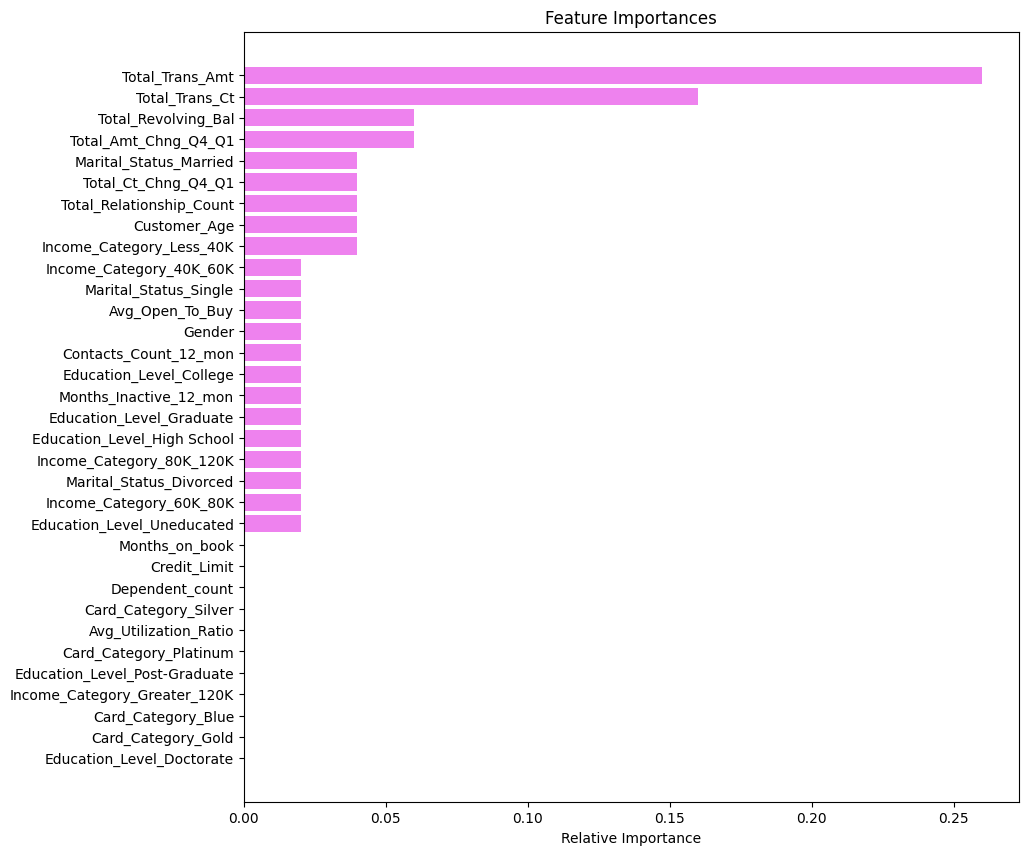

In [49]:
# Creating AdaBoost Feature Matrix using Over-Sampled Data

decision_tree = ada_classifier_ov

feature_importance_df = pd.DataFrame(decision_tree.feature_importances_, columns=['Importance'], index=X_train.columns).sort_values(by='Importance', ascending=False)
print('Feature Importance')
print(feature_importance_df)

feature_names = decision_tree.feature_names_in_
feature_importance = decision_tree.feature_importances_
indices = np.argsort(feature_importance)

plt.figure(figsize=(10,10))
plt.title('Feature Importances')
plt.barh(range(len(indices)), feature_importance[indices], color='violet', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show();

### Observations

1. Accuracy, Recall and Precision are all ~0.96, ~0.96, ~0.95 for Training Data.
2. In Testing Accuracy, Recall has reduced.
4. We will see how the Hyper-Parameter tuning and influence tehse numbers.

Imporant Features:
  - Total_Trans_Amt
  - Total_Trans_Ct
  - Total_Revolving_Bal
      - Feature Order remained the same.
      - Relative importance values of these metrics has changed.

In [50]:
# Create GradientBoost Base Model

gboost_classifier_ov = GradientBoostingClassifier(random_state=1)
gboost_classifier_ov.fit(X_train_over, y_train_over)

#Calculating Accuracy
print('Accuracy Base Score Training:', gboost_classifier_ov.score(X_train_over, y_train_over))
print('Accuracy Base Score Testing:', gboost_classifier_ov.score(X_test, y_test))

# Build Predic Variables
y_predict_train = gboost_classifier_ov.predict(X_train_over)
y_predict_test = gboost_classifier_ov.predict(X_test)

#Calculate Precision
print('Precision Base Score Training:', precision_score(y_train_over, y_predict_train))
print('Precision Base Score Testing:', precision_score(y_test, y_predict_test))

#Calculate Recall Score
print('Recall Base Score Training:', recall_score(y_train_over, y_predict_train))
print('Recall Base Score Testing:', recall_score(y_test, y_predict_test))

Accuracy Base Score Training: 0.9778268179907524
Accuracy Base Score Testing: 0.9584533113944879
Precision Base Score Training: 0.9819800720797117
Precision Base Score Testing: 0.9778325123152709
Recall Base Score Training: 0.9735182849936949
Recall Base Score Testing: 0.972562469377756


Feature Importance
                               Importance
Total_Trans_Ct                   0.503593
Total_Trans_Amt                  0.159368
Total_Revolving_Bal              0.101688
Total_Ct_Chng_Q4_Q1              0.080767
Total_Relationship_Count         0.050009
Marital_Status_Married           0.023279
Total_Amt_Chng_Q4_Q1             0.017444
Gender                           0.014086
Marital_Status_Single            0.011320
Customer_Age                     0.007615
Marital_Status_Divorced          0.004894
Months_Inactive_12_mon           0.004283
Education_Level_Graduate         0.003602
Education_Level_Uneducated       0.003169
Education_Level_High School      0.003164
Education_Level_College          0.001935
Avg_Utilization_Ratio            0.001676
Income_Category_Less_40K         0.001635
Contacts_Count_12_mon            0.001600
Avg_Open_To_Buy                  0.001054
Income_Category_60K_80K          0.001008
Income_Category_40K_60K          0.000887
Income_Category

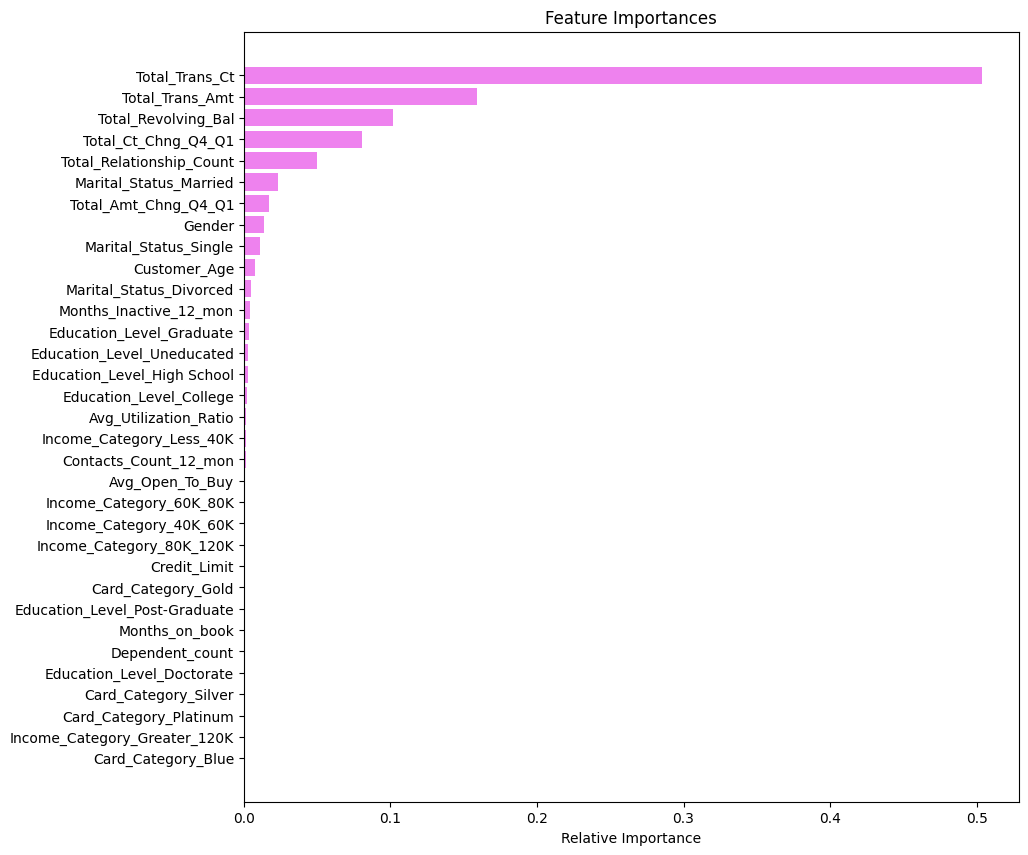

In [51]:
# Creating GradientBoost Feature Matrix using Over-Sampled Data

decision_tree = gboost_classifier_ov

feature_importance_df = pd.DataFrame(decision_tree.feature_importances_, columns=['Importance'], index=X_train.columns).sort_values(by='Importance', ascending=False)
print('Feature Importance')
print(feature_importance_df)

feature_names = decision_tree.feature_names_in_
feature_importance = decision_tree.feature_importances_
indices = np.argsort(feature_importance)

plt.figure(figsize=(10,10))
plt.title('Feature Importances')
plt.barh(range(len(indices)), feature_importance[indices], color='violet', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show();

### Observations

1. Accuracy, Recall and Precision have sligtly increased for Training Data.
2. In Testing Accuracy, Recall, Precision is also very very similar ~0.95, ~0.97, ~0.97.
4. We will see how the Hyper-Parameter tuning and influence tehse numbers.
5. The current result suggest that the Predictability in Testing is same as using Trainind data.

Imporant Features:
  - Total_Trans_Ct
  - Total_Trans_Amt
  - Total_Revolving_Bal
      - Feature Order has changed compared to Ada Boost.

### Model Building with Under-Sampled data

In [52]:
# Random undersampler for under sampling the data
rus = RandomUnderSampler(random_state=1, sampling_strategy=1)
X_train_un, y_train_un = rus.fit_resample(X_train, y_train)

y_train_un.value_counts()

Attrition_Flag
0    912
1    912
Name: count, dtype: int64

### Observations

1. We can see the '1' Class is Under Sampled

In [53]:
# Creating Base Decision Matrix - Under Sampled Data
# NO Pruning is done.

decision_tree_un = DecisionTreeClassifier(criterion='gini', random_state=1)
decision_tree_un.fit(X_train_un, y_train_un)

#Calculating Accuracy
print('Accuracy Base Score Training:', decision_tree_un.score(X_train_un, y_train_un))
print('Accuracy Base Score Testing:', decision_tree_un.score(X_test, y_test))

# Build Predic Variables
y_predict_train = decision_tree_un.predict(X_train_un)
y_predict_test = decision_tree_un.predict(X_test)

#Calculate Precision
print('Precision Base Score Training:', precision_score(y_train_un, y_predict_train))
print('Precision Base Score Testing:', precision_score(y_test, y_predict_test))

#Calculate Recall Score
print('Recall Base Score Training:', recall_score(y_train_un, y_predict_train))
print('Recall Base Score Testing:', recall_score(y_test, y_predict_test))

Accuracy Base Score Training: 1.0
Accuracy Base Score Testing: 0.8770053475935828
Precision Base Score Training: 1.0
Precision Base Score Testing: 0.9754366812227074
Recall Base Score Training: 1.0
Recall Base Score Testing: 0.8755512003919648


Feature Importance
                               Importance
Total_Trans_Ct                   0.444517
Total_Trans_Amt                  0.144968
Total_Revolving_Bal              0.106930
Total_Ct_Chng_Q4_Q1              0.091097
Total_Relationship_Count         0.046072
Total_Amt_Chng_Q4_Q1             0.045006
Customer_Age                     0.023741
Avg_Open_To_Buy                  0.016017
Contacts_Count_12_mon            0.015273
Dependent_count                  0.013985
Months_Inactive_12_mon           0.012597
Credit_Limit                     0.009510
Avg_Utilization_Ratio            0.006484
Months_on_book                   0.005278
Education_Level_High School      0.003634
Income_Category_40K_60K          0.003472
Marital_Status_Married           0.003411
Marital_Status_Divorced          0.002234
Card_Category_Platinum           0.002152
Education_Level_Uneducated       0.001949
Income_Category_80K_120K         0.001671
Card_Category_Blue               0.000000
Income_Category

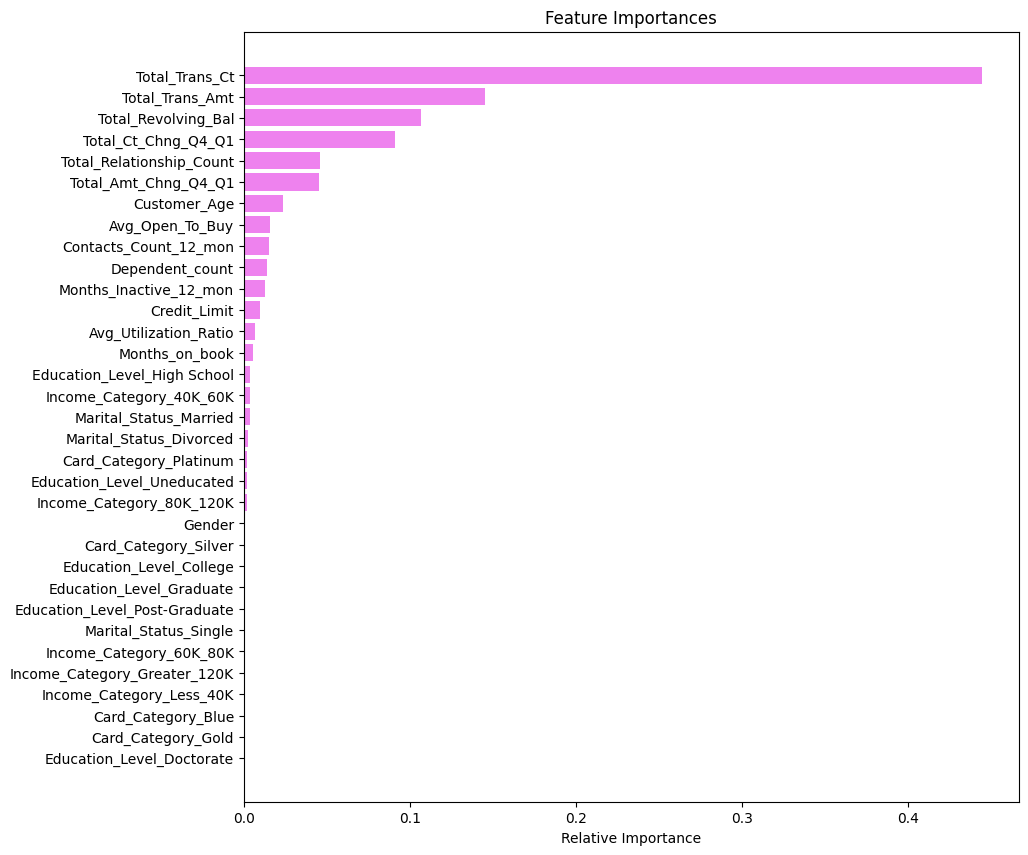

In [54]:
# Creating DecisionTree Feature Matrix using Under-Sampled Data

decision_tree = decision_tree_un

feature_importance_df = pd.DataFrame(decision_tree.feature_importances_, columns=['Importance'], index=X_train.columns).sort_values(by='Importance', ascending=False)
print('Feature Importance')
print(feature_importance_df)

feature_names = decision_tree.feature_names_in_
feature_importance = decision_tree.feature_importances_
indices = np.argsort(feature_importance)

plt.figure(figsize=(10,10))
plt.title('Feature Importances')
plt.barh(range(len(indices)), feature_importance[indices], color='violet', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show();

### Observations

1. Accuracy, Recall and Precision for Training are all around 1.
2. In Testing Accuracy, Recall, Precision is also very very similar ~0.89, ~0.97, ~0.90.
5. We will see how the Hyper-Parameter tuning and influence tehse numbers.


Imporant Features:
  - Total_Trans_Ct
  - Total_Trans_Amt
  - Total_Revolving_Bal

In [55]:
# Creating Base Bagging Classifier Matrix - Under-Sampled Dataset

bagging_classifier_un = BaggingClassifier(random_state=1)
bagging_classifier_un.fit(X_train_un, y_train_un)

#Calculating Accuracy
print('Accuracy Base Score Training:', bagging_classifier_un.score(X_train_un, y_train_un))
print('Accuracy Base Score Testing:', bagging_classifier_un.score(X_test, y_test))

# Build Predic Variables
y_predict_train = bagging_classifier_un.predict(X_train_un)
y_predict_test = bagging_classifier_un.predict(X_test)

#Calculate Precision
print('Precision Base Score Training:', precision_score(y_train_un, y_predict_train))
print('Precision Base Score Testing:', precision_score(y_test, y_predict_test))

#Calculate Recall Score
print('Recall Base Score Training:', recall_score(y_train_un, y_predict_train))
print('Recall Base Score Testing:', recall_score(y_test, y_predict_test))

Accuracy Base Score Training: 0.9945175438596491
Accuracy Base Score Testing: 0.8938708350473057
Precision Base Score Training: 0.9988938053097345
Precision Base Score Testing: 0.9879584017515052
Recall Base Score Training: 0.9901315789473685
Recall Base Score Testing: 0.8843704066634003


### Observations

1. Accuracy, Recall and Precision for Training have been reduced.
2. In Testing Accuracy, Recall, Precision is also very very similar ~0.91, ~0.98, ~0.90.
3. Recall has not improved.
5. We will see how the Hyper-Parameter tuning and influence tehse numbers.


In [56]:
# Creating base RandomForest Classifier Matrix - Under-Sampled Dataset

random_classifier_un = RandomForestClassifier(random_state=1)
random_classifier_un.fit(X_train_un, y_train_un)

#Calculating Accuracy
print('Accuracy Base Score Training:', random_classifier_un.score(X_train_un, y_train_un))
print('Accuracy Base Score Testing:', random_classifier_un.score(X_test, y_test))

# Build Predic Variables
y_predict_train = random_classifier_un.predict(X_train_un)
y_predict_test = random_classifier_un.predict(X_test)

#Calculate Precision
print('Precision Base Score Training:', precision_score(y_train_un, y_predict_train))
print('Precision Base Score Testing:', precision_score(y_test, y_predict_test))

#Calculate Recall Score
print('Recall Base Score Training:', recall_score(y_train_un, y_predict_train))
print('Recall Base Score Testing:', recall_score(y_test, y_predict_test))

Accuracy Base Score Training: 1.0
Accuracy Base Score Testing: 0.9169066227889757
Precision Base Score Training: 1.0
Precision Base Score Testing: 0.9857369255150554
Recall Base Score Training: 1.0
Recall Base Score Testing: 0.9142577168054875


Feature Importance
                               Importance
Total_Trans_Ct                   0.215731
Total_Trans_Amt                  0.170065
Total_Revolving_Bal              0.104024
Total_Ct_Chng_Q4_Q1              0.100059
Avg_Utilization_Ratio            0.059424
Total_Amt_Chng_Q4_Q1             0.058195
Total_Relationship_Count         0.038530
Credit_Limit                     0.034918
Avg_Open_To_Buy                  0.034509
Customer_Age                     0.027812
Contacts_Count_12_mon            0.026937
Months_on_book                   0.026060
Months_Inactive_12_mon           0.025797
Dependent_count                  0.015235
Gender                           0.009542
Marital_Status_Married           0.006652
Marital_Status_Single            0.004641
Income_Category_Less_40K         0.004038
Education_Level_High School      0.003952
Education_Level_Graduate         0.003897
Income_Category_40K_60K          0.003849
Education_Level_Uneducated       0.003706
Income_Category

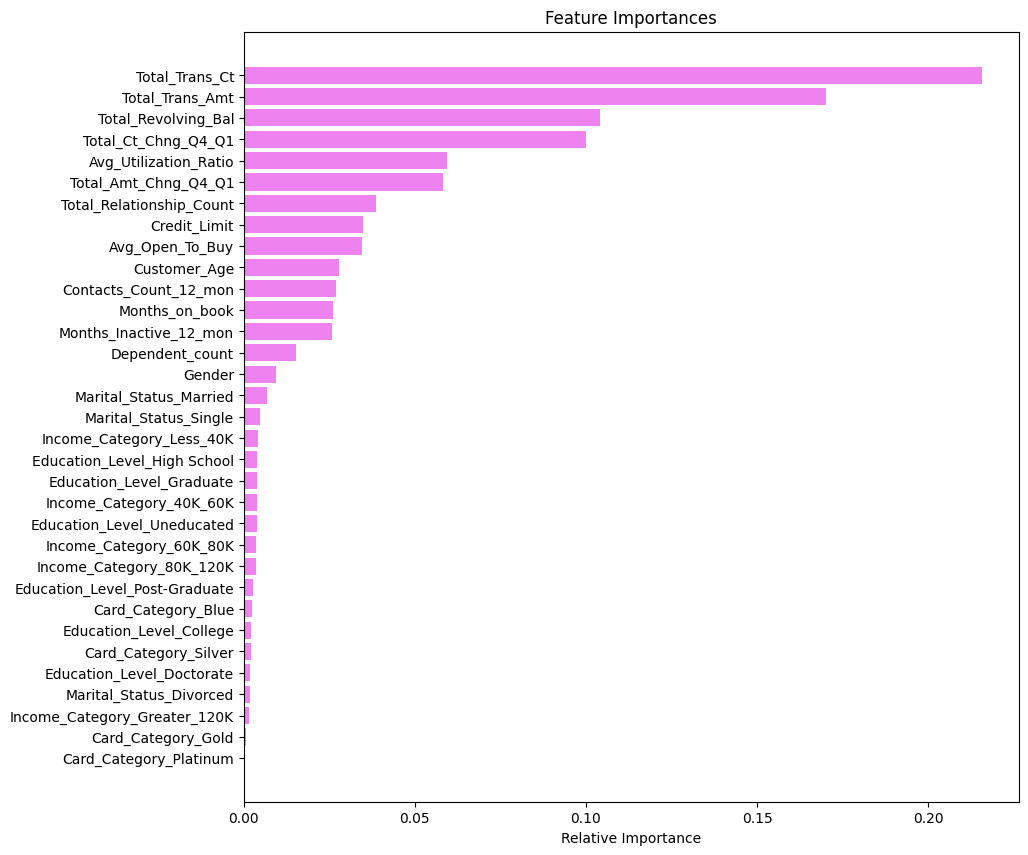

In [57]:
# Creating RandomForest Feature Matrix using Under-Sampled Data

decision_tree = random_classifier_un

feature_importance_df = pd.DataFrame(decision_tree.feature_importances_, columns=['Importance'], index=X_train.columns).sort_values(by='Importance', ascending=False)
print('Feature Importance')
print(feature_importance_df)

feature_names = decision_tree.feature_names_in_
feature_importance = decision_tree.feature_importances_
indices = np.argsort(feature_importance)

plt.figure(figsize=(10,10))
plt.title('Feature Importances')
plt.barh(range(len(indices)), feature_importance[indices], color='violet', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show();

### Observations

1. Accuracy, Recall and Precision for Training are all around 1.
2. In Testing Accuracy, Recall, Precision is also very very similar ~0.92, ~0.98, ~0.92.
5. We will see how the Hyper-Parameter tuning and influence tehse numbers.


Imporant Features:
  - Total_Trans_Ct
  - Total_Trans_Amt
  - Total_Revolving_Bal
    - There is a change in Feature importance.

In [58]:
# Creating Base AdaBoosting Classifier - Under Sampled Dataset

ada_classifier_un = AdaBoostClassifier(random_state=1)
ada_classifier_un.fit(X_train_un, y_train_un)

#Calculating Accuracy
print('Accuracy Base Score Training:', ada_classifier_un.score(X_train_un, y_train_un))
print('Accuracy Base Score Testing:', ada_classifier_un.score(X_test, y_test))

# Build Predic Variables
y_predict_train = ada_classifier_un.predict(X_train_un)
y_predict_test = ada_classifier_un.predict(X_test)

#Calculate Precision
print('Precision Base Score Training:', precision_score(y_train_un, y_predict_train))
print('Precision Base Score Testing:', precision_score(y_test, y_predict_test))

#Calculate Recall Score
print('Recall Base Score Training:', recall_score(y_train_un, y_predict_train))
print('Recall Base Score Testing:', recall_score(y_test, y_predict_test))

Accuracy Base Score Training: 0.9583333333333334
Accuracy Base Score Testing: 0.9284245166598107
Precision Base Score Training: 0.9623893805309734
Precision Base Score Testing: 0.9859448204060385
Recall Base Score Training: 0.9539473684210527
Recall Base Score Testing: 0.9279764821166095


Feature Importance
                               Importance
Total_Trans_Amt                      0.34
Total_Trans_Ct                       0.18
Total_Revolving_Bal                  0.10
Total_Amt_Chng_Q4_Q1                 0.06
Total_Ct_Chng_Q4_Q1                  0.06
Total_Relationship_Count             0.04
Months_Inactive_12_mon               0.04
Contacts_Count_12_mon                0.04
Gender                               0.02
Avg_Utilization_Ratio                0.02
Customer_Age                         0.02
Avg_Open_To_Buy                      0.02
Credit_Limit                         0.02
Months_on_book                       0.02
Marital_Status_Married               0.02
Income_Category_40K_60K              0.00
Card_Category_Gold                   0.00
Card_Category_Platinum               0.00
Card_Category_Blue                   0.00
Income_Category_Less_40K             0.00
Income_Category_Greater_120K         0.00
Income_Category_80K_120K             0.00
Income_Category

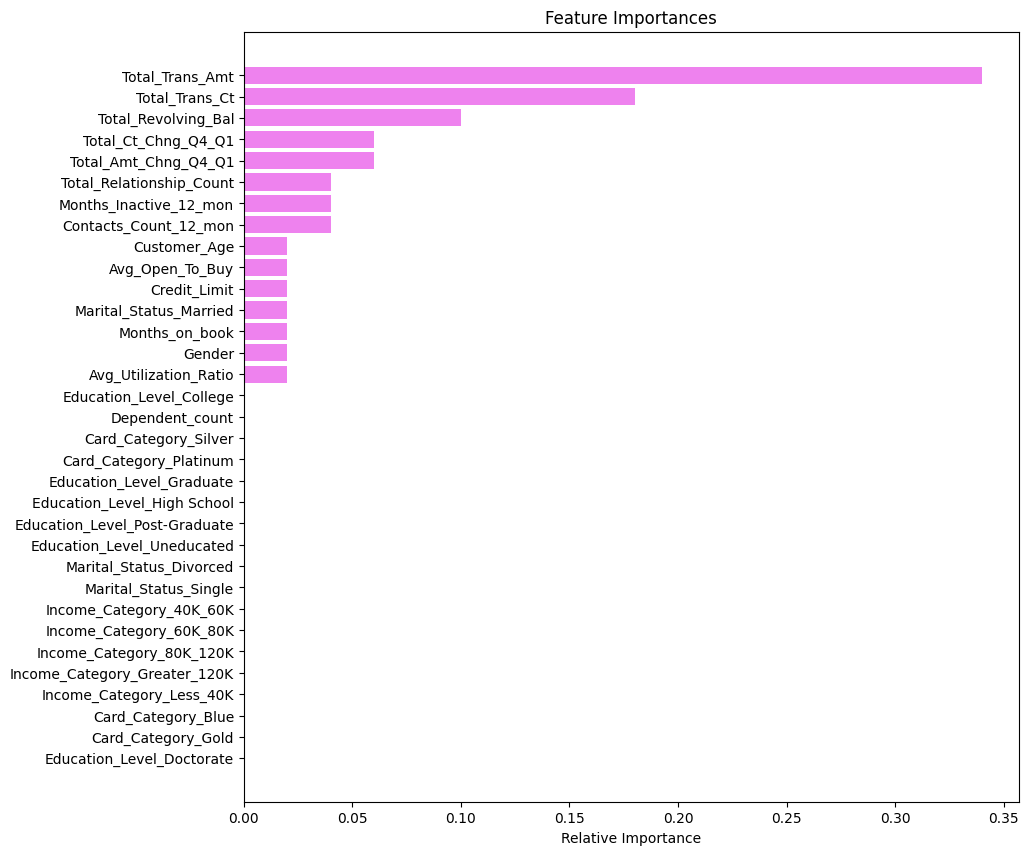

In [59]:
# Creating ADaBoost Feature Matrix using Under-Sampled Data

decision_tree = ada_classifier_un

feature_importance_df = pd.DataFrame(decision_tree.feature_importances_, columns=['Importance'], index=X_train.columns).sort_values(by='Importance', ascending=False)
print('Feature Importance')
print(feature_importance_df)

feature_names = decision_tree.feature_names_in_
feature_importance = decision_tree.feature_importances_
indices = np.argsort(feature_importance)

plt.figure(figsize=(10,10))
plt.title('Feature Importances')
plt.barh(range(len(indices)), feature_importance[indices], color='violet', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show();

### Observations

1. Accuracy, Recall and Precision for Training has reduced.
2. In Testing Accuracy, Recall, Precision is also very very similar ~0.92, ~0.98, ~0.92.
3. Not much change in values from RandomForest
5. We will see how the Hyper-Parameter tuning and influence tehse numbers.


Imporant Features:
  - Total_Trans_Amt
  - Total_Trans_Ct
  - Total_Revolving_Bal
    - There is a change in Feature importance.

In [60]:
# Create GradientBoost Base Model

gboost_classifier_un = GradientBoostingClassifier(random_state=1)
gboost_classifier_un.fit(X_train_un, y_train_un)

#Calculating Accuracy
print('Accuracy Base Score Training:', gboost_classifier_un.score(X_train_un, y_train_un))
print('Accuracy Base Score Testing:', gboost_classifier_un.score(X_test, y_test))

# Build Predic Variables
y_predict_train = gboost_classifier_un.predict(X_train_un)
y_predict_test = gboost_classifier_un.predict(X_test)

#Calculate Precision
print('Precision Base Score Training:', precision_score(y_train_un, y_predict_train))
print('Precision Base Score Testing:', precision_score(y_test, y_predict_test))

#Calculate Recall Score
print('Recall Base Score Training:', recall_score(y_train_un, y_predict_train))
print('Recall Base Score Testing:', recall_score(y_test, y_predict_test))

Accuracy Base Score Training: 0.9835526315789473
Accuracy Base Score Testing: 0.9370629370629371
Precision Base Score Training: 0.9910913140311804
Precision Base Score Testing: 0.9886128364389234
Recall Base Score Training: 0.9758771929824561
Recall Base Score Testing: 0.9358157765801078


Feature Importance
                               Importance
Total_Trans_Ct                   0.485281
Total_Trans_Amt                  0.187235
Total_Revolving_Bal              0.133317
Total_Ct_Chng_Q4_Q1              0.086938
Total_Relationship_Count         0.038727
Total_Amt_Chng_Q4_Q1             0.020935
Months_Inactive_12_mon           0.011277
Customer_Age                     0.010611
Contacts_Count_12_mon            0.007563
Avg_Open_To_Buy                  0.004873
Months_on_book                   0.004444
Avg_Utilization_Ratio            0.001976
Dependent_count                  0.001607
Marital_Status_Married           0.001563
Gender                           0.001435
Credit_Limit                     0.000773
Card_Category_Platinum           0.000732
Income_Category_60K_80K          0.000338
Education_Level_Doctorate        0.000240
Card_Category_Silver             0.000053
Card_Category_Blue               0.000037
Income_Category_Less_40K         0.000032
Education_Level

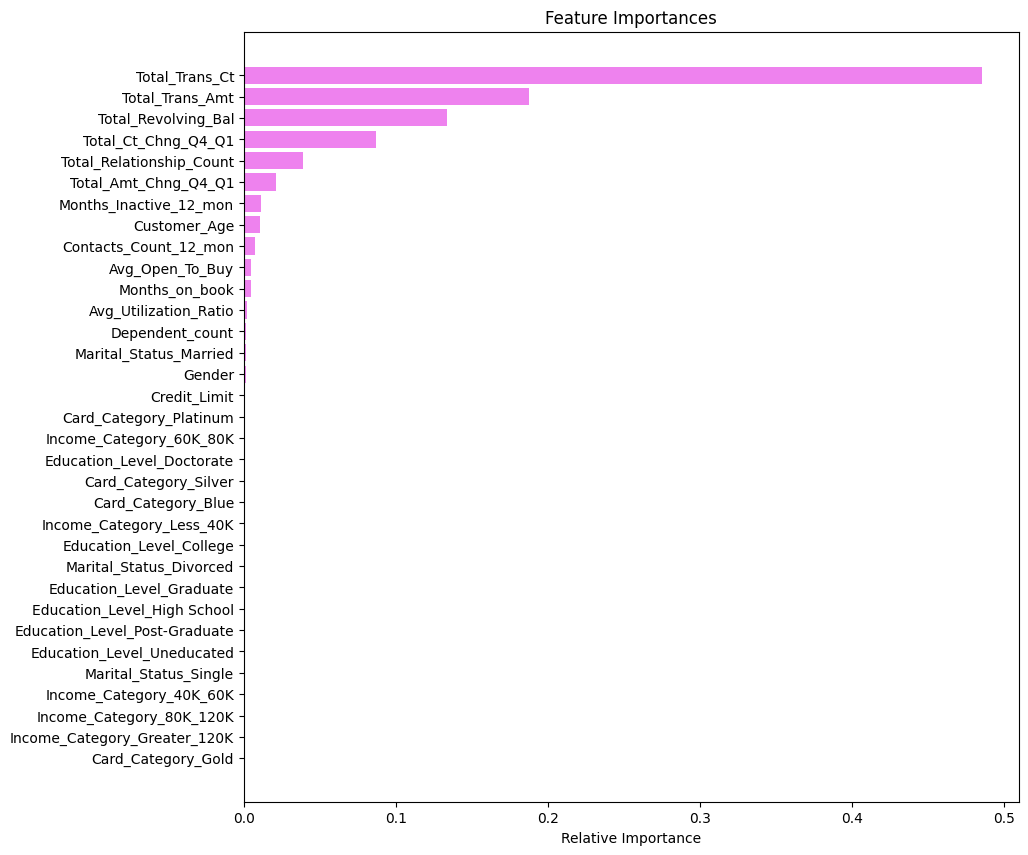

In [61]:
# Creating GradientBoost Feature Matrix using Under-Sampled Data

decision_tree = gboost_classifier_un

feature_importance_df = pd.DataFrame(decision_tree.feature_importances_, columns=['Importance'], index=X_train.columns).sort_values(by='Importance', ascending=False)
print('Feature Importance')
print(feature_importance_df)

feature_names = decision_tree.feature_names_in_
feature_importance = decision_tree.feature_importances_
indices = np.argsort(feature_importance)

plt.figure(figsize=(10,10))
plt.title('Feature Importances')
plt.barh(range(len(indices)), feature_importance[indices], color='violet', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show();

### Observations

1. Accuracy, Recall and Precision for Training is less than 1.
2. In Testing Accuracy, Recall, Precision is also very very similar ~0.94, ~0.94, ~0.94.
3. Change in Values is very small especially for Recall and Accuracy
5. We will see how the Hyper-Parameter tuning and influence tehse numbers.


Imporant Features:
  - Total_Trans_Ct
  - Total_Trans_Amt
  - Total_Revolving_Bal
    - There is chance in top feature between Adaboost and GradientBoost

## Choosing the Best Model from each List

We comsider only Recall for this decision

### *Orignal Data*

1. Decision Classifier
	- Recall Base Score Training: 1.0
	- Recall Base Score Testing: 0.9627597020776166

2. Bagging Classifier
	- Recall Base Score Training: 0.9972677595628415
	- Recall Base Score Testing: 0.979421852033317

3. RandomForest Classifier
	- Recall Base Score Training: 1.0
	- Recall Base Score Testing: 0.9882410583047526

4. AdaBoost Classifier
	- Recall Base Score Training: 0.9806641445985709
	- Recall Base Score Testing: 0.984811366976972

5. GradientBoot Classifier (**CHOICE FROM THIS GROUP**)
	- Recall Base Score Training: 0.9936948297604036
	- Recall Base Score Testing: 0.9887310142087212


## *OverSampled Data*

1. Decision Classifier
	- Recall Base Score Training: 1.0
	- Recall Base Score Testing: 0.945124938755512

2. Bagging Classifier
	- Recall Base Score Training: 0.9951660361496427
	- Recall Base Score Testing: 0.953454189122979

3. RandomForest Classifier
	- Recall Base Score Training: 1.0
	- Recall Base Score Testing: 0.9696227339539442

4. AdaBoost Classifier
	- Recall Base Score Training: 0.9602774274905422
	- Recall Base Score Testing: 0.964233219010289

5. GradientBoost Classifier (**CHOICE FROM THIS GROUP**)
	- Recall Base Score Training: 0.9735182849936949
	- Recall Base Score Testing: 0.972562469377756


## *UnderSampled Data*

1. Decision Classifier
	- Recall Base Score Training: 1.0
	- Recall Base Score Testing: 0.8755512003919648

2. Bagging Classifier
	- Recall Base Score Training: 0.9901315789473685
	- Recall Base Score Testing: 0.8843704066634003

3. RandomClassifier
	- Recall Base Score Training: 1.0
	- Recall Base Score Testing: 0.9142577168054875

4. AdaBoost Classifier
	- Recall Base Score Training: 0.9539473684210527
	- Recall Base Score Testing: 0.9279764821166095

5. GradientBoost Classifier (**CHOICE FROM THIS GROUP**)
	- Recall Base Score Training: 0.9758771929824561
	- Recall Base Score Testing: 0.9358157765801078

### Hyper-Tuning all three Models Categories

### Original Data

In [62]:
# Create Model using Gradient Boost Classifier - Original Dataset

gboost_classifier = GradientBoostingClassifier(random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid = {
    "init": [AdaBoostClassifier(random_state=1),DecisionTreeClassifier(random_state=1)],
    "n_estimators": np.arange(50,110,25),
    "learning_rate": [0.01,0.1,0.05],
    "subsample":[0.7,0.9],
    "max_features":[0.5,0.7,1],
}

scorer = make_scorer(recall_score)

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=gboost_classifier, param_distributions=param_grid, n_iter=10, n_jobs = -1, scoring=scorer, cv=5, random_state=1)
randomized_cv.fit(X_train,y_train)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'subsample': 0.7, 'n_estimators': 50, 'max_features': 1, 'learning_rate': 0.05, 'init': AdaBoostClassifier(random_state=1)} with CV score=0.9997899159663867:


### Observations

1. We will build the GradientBoost Classifier using following
  - Grid Param - {'subsample': 0.7, 'n_estimators': 50, 'max_features': 1, 'learning_rate': 0.05, 'init': AdaBoostClassifier(random_state=1)}
  - Corss-Validation Score = 0.9997


In [63]:
# Building Tuned GradientBoost Model - Original Data

gboost_classifier_tuned_orig = GradientBoostingClassifier(subsample=0.7, n_estimators=50, max_features=1, learning_rate=0.05, init=AdaBoostClassifier(random_state=1))
gboost_classifier_tuned_orig.fit(X_train, y_train)

#Calculating Accuracy
print('Accuracy Base Score Training:', gboost_classifier_tuned_orig.score(X_train, y_train))
print('Accuracy Base Score Testing:', gboost_classifier_tuned_orig.score(X_test, y_test))

# Build Predic Variables
y_predict_train = gboost_classifier_tuned_orig.predict(X_train)
y_predict_test = gboost_classifier_tuned_orig.predict(X_test)

#Calculate Precision
print('Precision Base Score Training:', precision_score(y_train, y_predict_train))
print('Precision Base Score Testing:', precision_score(y_test, y_predict_test))

#Calculate Recall Score
print('Recall Base Score Training:', recall_score(y_train, y_predict_train))
print('Recall Base Score Testing:', recall_score(y_test, y_predict_test))

Accuracy Base Score Training: 0.852910052910053
Accuracy Base Score Testing: 0.8527354997943233
Precision Base Score Training: 0.8509838998211091
Precision Base Score Testing: 0.8507711546477699
Recall Base Score Training: 0.9997898276586801
Recall Base Score Testing: 1.0


### Observations

0. For Original DataSet.
  1. Recall Score After Tuning:
    - Training = 1
    - Testing = 1
  2. Recall Score with out Tuning:
    - Training = 0.9936948297604036
    - Testing = 0.9887310142087212

In [64]:
# Running Evaluation Dataset on the Tuned Model with Original Dataset

y_predict_eval = gboost_classifier_tuned_orig.predict(X_eval)

print('Accuracy Base Score Evaluation Data:', gboost_classifier_tuned_orig.score(X_eval, y_eval))
print('Precision Base Score Evaluation Data:', precision_score(y_eval, y_predict_eval))
print('Recall Base Score Evaluation Data:', recall_score(y_eval, y_predict_eval))

Accuracy Base Score Evaluation Data: 0.8489634748272458
Precision Base Score Evaluation Data: 0.8478802992518704
Recall Base Score Evaluation Data: 0.9994121105232217


### Over Sampled Dataset

In [65]:
# Create Model using Gradient Boost Classifier - Over-Sampled Dataset

gboost_classifier = GradientBoostingClassifier(random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid = {
    "init": [AdaBoostClassifier(random_state=1),DecisionTreeClassifier(random_state=1)],
    "n_estimators": np.arange(50,110,25),
    "learning_rate": [0.01,0.1,0.05],
    "subsample":[0.7,0.9],
    "max_features":[0.5,0.7,1],
}

scorer = make_scorer(recall_score)

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=gboost_classifier, param_distributions=param_grid, n_iter=10, n_jobs = -1, scoring=scorer, cv=5, random_state=1)
randomized_cv.fit(X_train_over,y_train_over)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'subsample': 0.7, 'n_estimators': 100, 'max_features': 0.7, 'learning_rate': 0.05, 'init': DecisionTreeClassifier(random_state=1)} with CV score=0.9409396566197457:


In [66]:
# Building Tuned GradientBoost Model - Over Sampled Data

gboost_classifier_tuned_ov = GradientBoostingClassifier(subsample=0.7, n_estimators=100, max_features=0.7, learning_rate=0.05, init=DecisionTreeClassifier(random_state=1))
gboost_classifier_tuned_ov.fit(X_train_over, y_train_over)

#Calculating Accuracy
print('Accuracy Base Score Training:', gboost_classifier_tuned_ov.score(X_train_over, y_train_over))
print('Accuracy Base Score Testing:', gboost_classifier_tuned_ov.score(X_test, y_test))

# Build Predic Variables
y_predict_train = gboost_classifier_tuned_ov.predict(X_train_over)
y_predict_test = gboost_classifier_tuned_ov.predict(X_test)

#Calculate Precision
print('Precision Base Score Training:', precision_score(y_train_over, y_predict_train))
print('Precision Base Score Testing:', precision_score(y_test, y_predict_test))

#Calculate Recall Score
print('Recall Base Score Training:', recall_score(y_train_over, y_predict_train))
print('Recall Base Score Testing:', recall_score(y_test, y_predict_test))

Accuracy Base Score Training: 1.0
Accuracy Base Score Testing: 0.9271904566022213
Precision Base Score Training: 1.0
Precision Base Score Testing: 0.9674022066198595
Recall Base Score Training: 1.0
Recall Base Score Testing: 0.945124938755512


### Observations

0. For Over Sampled DataSet.
  1. Recall Score After Tuning:
    - Training = 1
    - Testing = 0.9451
  2. Recall Score with out Tuning:
    - Training = 0.9735
    - Testing = 0.9725

In [67]:
# Running Evaluation Dataset on the Tuned Model with Over-Sampled Dataset

y_predict_eval = gboost_classifier_tuned_ov.predict(X_eval)

print('Accuracy Base Score Evaluation Data:', gboost_classifier_tuned_ov.score(X_eval, y_eval))
print('Precision Base Score Evaluation Data:', precision_score(y_eval, y_predict_eval))
print('Recall Base Score Evaluation Data:', recall_score(y_eval, y_predict_eval))

Accuracy Base Score Evaluation Data: 0.9274432379072063
Precision Base Score Evaluation Data: 0.9652694610778443
Recall Base Score Evaluation Data: 0.9476778365667254


### Under-Sampled Dataset

In [68]:
# Create Model using Gradient Boost Classifier - Under Sampled  Dataset

gboost_classifier = GradientBoostingClassifier(random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid = {
    "init": [AdaBoostClassifier(random_state=1),DecisionTreeClassifier(random_state=1)],
    "n_estimators": np.arange(50,110,25),
    "learning_rate": [0.01,0.1,0.05],
    "subsample":[0.7,0.9],
    "max_features":[0.5,0.7,1],
}

scorer = make_scorer(recall_score)

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=gboost_classifier, param_distributions=param_grid, n_iter=10, n_jobs = -1, scoring=scorer, cv=5, random_state=1)
randomized_cv.fit(X_train_un,y_train_un)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'subsample': 0.7, 'n_estimators': 100, 'max_features': 0.7, 'learning_rate': 0.05, 'init': DecisionTreeClassifier(random_state=1)} with CV score=0.8837927100222183:


In [69]:
# Building Tuned GradientBoost Model - Under Sampled Data

gboost_classifier_tuned_un = GradientBoostingClassifier(subsample=0.7, n_estimators=100, max_features=0.7, learning_rate=0.05, init=DecisionTreeClassifier(random_state=1))
gboost_classifier_tuned_un.fit(X_train_un, y_train_un)

#Calculating Accuracy
print('Accuracy Base Score Training:', gboost_classifier_tuned_un.score(X_train_un, y_train_un))
print('Accuracy Base Score Testing:', gboost_classifier_tuned_un.score(X_test, y_test))

# Build Predic Variables
y_predict_train = gboost_classifier_tuned_un.predict(X_train_un)
y_predict_test = gboost_classifier_tuned_un.predict(X_test)

#Calculate Precision
print('Precision Base Score Training:', precision_score(y_train_un, y_predict_train))
print('Precision Base Score Testing:', precision_score(y_test, y_predict_test))

#Calculate Recall Score
print('Recall Base Score Training:', recall_score(y_train_un, y_predict_train))
print('Recall Base Score Testing:', recall_score(y_test, y_predict_test))

Accuracy Base Score Training: 1.0
Accuracy Base Score Testing: 0.8770053475935828
Precision Base Score Training: 1.0
Precision Base Score Testing: 0.9754366812227074
Recall Base Score Training: 1.0
Recall Base Score Testing: 0.8755512003919648


### Observations

0. For Under Sampled DataSet.
  1. Recall Score After Tuning:
    - Training = 1
    - Testing = 0.8755
  2. Recall Score with out Tuning:
    - Training = 0.9758
    - Testing = 0.9358

In [70]:
# Running Evaluation Dataset on the Tuned Model with Under-Sampled Dataset

y_predict_eval = gboost_classifier_tuned_un.predict(X_eval)

print('Accuracy Base Score Evaluation Data:', gboost_classifier_tuned_un.score(X_eval, y_eval))
print('Precision Base Score Evaluation Data:', precision_score(y_eval, y_predict_eval))
print('Recall Base Score Evaluation Data:', recall_score(y_eval, y_predict_eval))

Accuracy Base Score Evaluation Data: 0.8854886475814413
Precision Base Score Evaluation Data: 0.9766385463984426
Recall Base Score Evaluation Data: 0.8847736625514403


### Evaluation of Models

**Evaluation Score of Model Trained with Original Data**
  - Accuracy  = 0.8479
  - Precision = 0.8470
  - Recall    = 0.9994

**Evaluation Score of Model Trained with Over-Sampled Data**
  - Accuracy  = 0.9274
  - Precision = 0.9652
  - Recall    = 0.9476

**Evaluation Score of Model Trained with Under-Sampled Data**
  - Accuracy  = 0.8854
  - Precision = 0.9766
  - Recall    = 0.8847


### **Model Choices**
  - I will choose the Model that was trained with Over-Sampling
  - Reason:
    - This is High Recall and Precision on Evaluation Data.
    - Accuracy is also High for this model in comparison with other two.

Feature Importance
                               Importance
Total_Trans_Ct                   0.441512
Total_Trans_Amt                  0.191055
Total_Revolving_Bal              0.113727
Total_Ct_Chng_Q4_Q1              0.082533
Total_Relationship_Count         0.056080
Marital_Status_Married           0.022412
Gender                           0.017567
Total_Amt_Chng_Q4_Q1             0.016986
Marital_Status_Single            0.011283
Customer_Age                     0.010377
Avg_Utilization_Ratio            0.010248
Months_Inactive_12_mon           0.005476
Education_Level_High School      0.003509
Education_Level_Graduate         0.002921
Marital_Status_Divorced          0.002875
Education_Level_Uneducated       0.002799
Income_Category_60K_80K          0.001538
Avg_Open_To_Buy                  0.001533
Education_Level_College          0.001357
Income_Category_40K_60K          0.000957
Months_on_book                   0.000747
Credit_Limit                     0.000743
Contacts_Count_

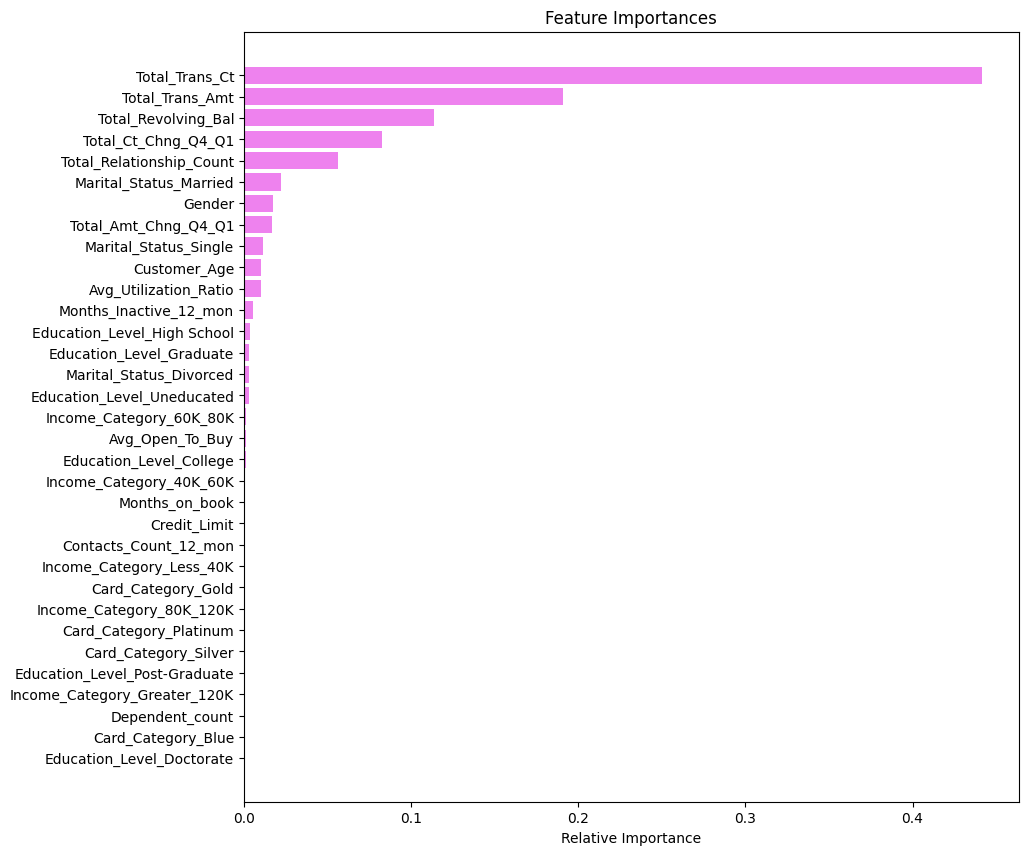

In [71]:
# Get the Feature Importance on Selected Tuned Model

decision_tree = gboost_classifier_tuned_ov

feature_importance_df = pd.DataFrame(decision_tree.feature_importances_, columns=['Importance'], index=X_train.columns).sort_values(by='Importance', ascending=False)
print('Feature Importance')
print(feature_importance_df)

feature_names = decision_tree.feature_names_in_
feature_importance = decision_tree.feature_importances_
indices = np.argsort(feature_importance)

plt.figure(figsize=(10,10))
plt.title('Feature Importances')
plt.barh(range(len(indices)), feature_importance[indices], color='violet', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show();

## Business Insights and Conclusions

1. As part of Model Training & Testing consistant set of features that was showing up that will help reduce attrition are:
  - Total_Trans_Ct
  - Total_Trans_Amt
  - Total_Revolving_Bal
  - Total_Ct_Change_Q4_Q1

2. The same set of Features is also showing in seleced ML Model.

3. If Customers can be provided with Products that will help them to keep their spend with the bank, they will stay.

4. This could be providing new product features, reducing Fees / Surcharges etc..